# Calcium Imaging Analysis Pipeline

load Suite2P output for neurons (red) and astrocytes (green), compute
dF/F / z-scored activity, extract CS+/Trace/US trials, sort cells

In [154]:
from pathlib import Path
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import savgol_filter

from rastermap import Rastermap

In [155]:
sns.set_style("ticks")

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Consistent colors
NEURON_RED = "#C62828"
NEURON_RED_LIGHT = "#EF9A9A"
NEURON_RED_MID = "#E57373"

ASTRO_GREEN = "#2E7D32"
ASTRO_GREEN_LIGHT = "#A5D6A7"
ASTRO_GREEN_MID = "#66BB6A"

BLACK = "#222222"
GRAY = "#777777"

In [ ]:
# PATHS, TRIAL STRUCTURE

base_dir = Path(r"D:\ImagingData\Processed\Chandler\friends_chandler_day2_06162026_extracted")

output_root = base_dir / "analysis_outputs_basic_pipeline"
output_dirs = {
    "trial_average": output_root / "01_trial_average",
    "epoch_quantification": output_root / "02_epoch_quantification",
    "trial_by_trial": output_root / "03_trial_by_trial",
    "shock_aligned": output_root / "04_shock_aligned",
    "tables": output_root / "05_tables",
    "epoch_traces": output_root / "06_epoch_traces",
}

for folder in output_dirs.values():
    folder.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:")
for name, folder in output_dirs.items():
    print(f"  {name}: {folder}")


def find_suite2p_dir(base_dir, channel_dir):
    candidates = [
        base_dir / channel_dir / 'plane0',
        base_dir / channel_dir / 'suite2p' / 'plane0',
        base_dir / 'suite2p' / channel_dir / 'plane0',
        base_dir / channel_dir / 'suite2p_outputs' / 'plane0',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find Suite2P plane0 folder for {channel_dir}. "
        f"Checked: {', '.join(str(p) for p in candidates)}"
    )

# Acquisition
total_hz = 20.4
per_channel_hz = total_hz / 2  # 10.2 Hz per color channel

# Trial structure
BASELINE_START = 0
BASELINE_END = 120
TRIAL_ITI = 120
TRIAL_LENGTH = 50

# Extra window shown before CS+ onset (t=0) so trials include a visible pre-stimulus baseline
PRE_CS_WINDOW = 5

CS_START = 0
CS_END = 20
TRACE_START = 20
TRACE_END = 40
US_START = 40
US_END = 50

TRIAL_WINDOW = TRIAL_LENGTH

tone_times_sec = np.array([120, 280, 440, 600, 760], dtype=float)

shock_time_sec = tone_times_sec + US_START

DATASETS = {
    "neurons": {
        "s2p_dir": find_suite2p_dir(base_dir, "suite2p_red"),
        "signal_type": "spks",
        # Real per-frame acquisition timestamps (ms) 
        "frame_times_file": base_dir / "frame_times_ms_red.npy",
        "cmap": "Reds",
        "main_color": NEURON_RED,
        "epoch_colors": {
            "CS+": NEURON_RED_LIGHT,
            "Trace": NEURON_RED_MID,
            "US": NEURON_RED,
        },
        "ylabel": "Neuron #",
        "label": "Neurons",
    },
    "astrocytes": {
        "s2p_dir": find_suite2p_dir(base_dir, "suite2p_green"),
        "signal_type": "dff",
        "frame_times_file": base_dir / "frame_times_ms_green.npy",
        "cmap": "Greens",
        "main_color": ASTRO_GREEN,
        "epoch_colors": {
            "CS+": ASTRO_GREEN_LIGHT,
            "Trace": ASTRO_GREEN_MID,
            "US": ASTRO_GREEN,
        },
        "ylabel": "Astrocyte #",

        "label": "Astrocytes",}
    }

Saving outputs to:
  trial_average: D:\ImagingData\Processed\Chandler\friends_chandler_day2_06162026_extracted\analysis_outputs_basic_pipeline\01_trial_average
  epoch_quantification: D:\ImagingData\Processed\Chandler\friends_chandler_day2_06162026_extracted\analysis_outputs_basic_pipeline\02_epoch_quantification
  trial_by_trial: D:\ImagingData\Processed\Chandler\friends_chandler_day2_06162026_extracted\analysis_outputs_basic_pipeline\03_trial_by_trial
  shock_aligned: D:\ImagingData\Processed\Chandler\friends_chandler_day2_06162026_extracted\analysis_outputs_basic_pipeline\04_shock_aligned
  tables: D:\ImagingData\Processed\Chandler\friends_chandler_day2_06162026_extracted\analysis_outputs_basic_pipeline\05_tables
  epoch_traces: D:\ImagingData\Processed\Chandler\friends_chandler_day2_06162026_extracted\analysis_outputs_basic_pipeline\06_epoch_traces


In [ ]:

def save_figure(fig, out_path_base, dpi=600):
    """
    Save both SVG and PNG.
    out_path_base should be a Path WITHOUT extension.
    """
    fig.savefig(str(out_path_base) + ".svg", dpi=dpi, bbox_inches="tight")
    fig.savefig(str(out_path_base) + ".png", dpi=dpi, bbox_inches="tight")


def ensure_cells_x_time(traces, timestamps):
    """
    Ensure array is cells x time.
    """
    return traces.T if traces.shape[0] == len(timestamps) else traces


def sec_to_idx(t_rel, sec):
    return np.argmin(np.abs(t_rel - sec))


def add_trial_epoch_lines(ax, t_rel, color="white", lw=0.75):
    ax.axvline(sec_to_idx(t_rel, CS_START) + 0.5, color=color, linestyle="--", lw=lw)
    ax.axvline(sec_to_idx(t_rel, TRACE_START) + 0.5, color=color, linestyle="--", lw=lw)
    ax.axvline(sec_to_idx(t_rel, US_START) + 0.5, color=color, linestyle="--", lw=lw)


def style_axis(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("black")
    ax.tick_params(width=0.8, length=2.5)


def make_rastermap(**prefs):

    sig = inspect.signature(Rastermap)
    have = set(sig.parameters.keys())

    if {"n_clusters", "n_PCs", "locality", "time_lag_window"}.issubset(have):
        kwargs = dict(
            n_clusters=50,
            n_PCs=50,
            locality=0.5,
            time_lag_window=10,
            grid_upsample=10
        )
    elif {"n_X", "alpha", "n_PCs"}.issubset(have):
        kwargs = dict(
            n_X=50,
            alpha=1.0,
            n_PCs=50,
            timelag=10
        )
    elif {"n_components", "n_neighbors", "n_pcs"}.issubset(have):
        kwargs = dict(
            n_components=1,
            n_neighbors=50,
            n_pcs=50,
            n_epochs=500,
            learning_rate=1.0,
            random_state=0
        )
    else:
        kwargs = {}

    kwargs.update(prefs)
    return Rastermap(**kwargs)

In [ ]:
# LOAD SUITE2P DATA

def load_suite2p_dataset(dataset_name, cfg, per_channel_hz=10.2):
    """
    Load either neuron spks or astrocyte dFF.

    Returns dict with:
        traces: cells x time
        time: seconds
        shock_times, tone_times, trace_times
    """
    s2p_dir = cfg["s2p_dir"]

    iscell = np.load(s2p_dir / "iscell.npy", allow_pickle=True)
    cell_mask = iscell[:, 0].astype(bool)

    if cfg["signal_type"] == "spks":
        spks = np.load(s2p_dir / "spks.npy")
        traces = spks[cell_mask, :]

    elif cfg["signal_type"] == "dff":
        F = np.load(s2p_dir / "F.npy")
        Fneu = np.load(s2p_dir / "Fneu.npy")

        F_cells = F[cell_mask, :]
        Fneu_cells = Fneu[cell_mask, :]

        # Neuropil correction
        Fcorr = F_cells - 0.7 * Fneu_cells

        # Baseline
        window_length = 501
        if window_length >= Fcorr.shape[1]:
            window_length = Fcorr.shape[1] - 1
        if window_length % 2 == 0:
            window_length -= 1

        baseline = savgol_filter(
            Fcorr,
            window_length=window_length,
            polyorder=3,
            axis=1
        )
        baseline[baseline == 0] = np.nan

        traces = (Fcorr - baseline) / baseline
        traces = np.nan_to_num(traces, nan=0.0, posinf=0.0, neginf=0.0)

    else:
        raise ValueError("signal_type must be 'spks' or 'dff'")

    frame_times_file = cfg.get("frame_times_file")
    if frame_times_file is not None and Path(frame_times_file).exists():
        # Real per-frame timestamps 
        frame_times_ms = np.load(frame_times_file)[: traces.shape[1]]
        traces = traces[:, : len(frame_times_ms)]
        time = (frame_times_ms - frame_times_ms[0]) / 1000.0
    else:
        print(f"  WARNING: no frame_times file for {dataset_name}, falling back to uniform {per_channel_hz} Hz")
        time = np.arange(traces.shape[1]) / per_channel_hz

    # Event timing 
    tone_times = tone_times_sec
    shock_times = shock_time_sec
    trace_times = tone_times_sec + TRACE_START

    print(f"\nLoaded {dataset_name}")
    print("  traces shape:", traces.shape)
    print("  recording duration (min):", np.round(time[-1] / 60, 2))
    print("  tone times:", np.round(tone_times, 2))
    print("  shock times:", np.round(shock_times, 2))

    return {
        "traces": traces,
        "time": time,
        "shock_times": shock_times,
        "tone_times": tone_times,
        "trace_times": trace_times,
    }

In [ ]:
# TRIAL EXTRACTION

def extract_trials(traces, timestamps, tone_events, trial_window=50, window_before=0.0, zscore=True):
    """
    Returns:
        trial_data: cells x trials x timepoints
        t_rel: time from CS+ onset (starts at -window_before)
    """
    timestamps = np.asarray(timestamps, dtype=float)
    tone_events = np.asarray(tone_events, dtype=float)

    data = ensure_cells_x_time(traces, timestamps)

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(np.round((trial_window + window_before) * fs))
    t_rel = np.arange(n_points) / fs - window_before

    all_cells = []

    for sig in data:
        chunks = []

        for tone in tone_events:
            t_win = tone + t_rel

            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            chunks.append(chunk)

        if len(chunks) == 0:
            all_cells.append(np.full((len(tone_events), n_points), np.nan))
            continue

        chunks = np.vstack(chunks)

        if zscore:
            m = np.nanmean(chunks)
            s = np.nanstd(chunks)
            if s == 0 or np.isnan(s):
                s = 1
            chunks = (chunks - m) / s

        all_cells.append(chunks)

    trial_data = np.stack(all_cells, axis=0)
    return trial_data, t_rel

In [ ]:
# EPOCH METRICS

def make_epoch_response_df(avg_trial_by_cell, t_rel):
    """
    Per-cell epoch responses from trial-averaged activity.
    """
    cs_idx0 = sec_to_idx(t_rel, CS_START)
    cs_idx1 = sec_to_idx(t_rel, CS_END)

    trace_idx0 = sec_to_idx(t_rel, TRACE_START)
    trace_idx1 = sec_to_idx(t_rel, TRACE_END)

    us_idx0 = sec_to_idx(t_rel, US_START)
    us_idx1 = sec_to_idx(t_rel, US_END)

    cs_mean = np.nanmean(avg_trial_by_cell[:, cs_idx0:cs_idx1], axis=1)
    trace_mean = np.nanmean(avg_trial_by_cell[:, trace_idx0:trace_idx1], axis=1)
    us_mean = np.nanmean(avg_trial_by_cell[:, us_idx0:us_idx1], axis=1)
    us_max = np.nanmax(avg_trial_by_cell[:, us_idx0:us_idx1], axis=1)

    response_df = pd.DataFrame({
        "cell": np.arange(avg_trial_by_cell.shape[0]),
        "CS+": cs_mean,
        "Trace": trace_mean,
        "US": us_mean,
        "US_max": us_max,
    })

    return response_df


def make_trialwise_population_df(trial_data, t_rel):
    """
    Population mean response across trials for each epoch.
    Returns long-format DataFrame.
    """
    n_cells, n_trials, _ = trial_data.shape

    cs_idx0 = sec_to_idx(t_rel, CS_START)
    cs_idx1 = sec_to_idx(t_rel, CS_END)

    trace_idx0 = sec_to_idx(t_rel, TRACE_START)
    trace_idx1 = sec_to_idx(t_rel, TRACE_END)

    us_idx0 = sec_to_idx(t_rel, US_START)
    us_idx1 = sec_to_idx(t_rel, US_END)

    cs_by_trial = np.nanmean(trial_data[:, :, cs_idx0:cs_idx1], axis=(0, 2))
    trace_by_trial = np.nanmean(trial_data[:, :, trace_idx0:trace_idx1], axis=(0, 2))
    us_by_trial = np.nanmean(trial_data[:, :, us_idx0:us_idx1], axis=(0, 2))

    df = pd.DataFrame({
        "trial": np.arange(1, n_trials + 1),
        "CS+": cs_by_trial,
        "Trace": trace_by_trial,
        "US": us_by_trial,
    })

    return df

In [ ]:
# RASTERMAP 

def run_rastermap_on_trials(trial_data):
    """
    Fit Rastermap on concatenated trial-by-trial activity.

    Returns:
        raster_order: original cell indices in Rastermap order
        data_concat_sorted: sorted concatenated trial matrix
        valid_cells: boolean mask on original cells
    """
    n_cells, n_trials, n_time = trial_data.shape
    data_concat = trial_data.reshape(n_cells, n_trials * n_time)

    valid_cells = (
            np.isfinite(data_concat).all(axis=1) &
            (np.nanstd(data_concat, axis=1) > 0)
    )

    data_valid = data_concat[valid_cells]
    data_valid_z = stats.zscore(data_valid, axis=1, nan_policy="omit")
    data_valid_z = np.nan_to_num(data_valid_z, nan=0.0)

    rm = make_rastermap()
    rm.fit(data_valid_z)

    embedding = rm.embedding
    if embedding.ndim == 2:
        order_valid = np.argsort(embedding[:, 0])
    else:
        order_valid = np.argsort(embedding)

    original_valid_cell_ids = np.where(valid_cells)[0]
    raster_order = original_valid_cell_ids[order_valid]

    data_concat_sorted = data_concat[raster_order, :]

    return raster_order, data_concat_sorted, valid_cells

In [ ]:
# SHOCK-ALIGNED MATRIX

def make_shock_aligned_matrix(traces, timestamps, shock_times, window=10, sort_by="peak_time"):
    """
    Build shock-aligned mean response matrix and sort it.

    Returns:
        z_plot: sorted heatmap matrix
        sort_idx: row order in original cell coordinates
        z_unsorted: unsorted z-scored matrix
        t_rel_event: event-aligned time vector
    """
    timestamps = np.asarray(timestamps, dtype=float)
    shock_times = np.asarray(shock_times, dtype=float)

    data = ensure_cells_x_time(traces, timestamps)

    fs = 1.0 / np.median(np.diff(timestamps))
    n_points = int(np.round(window * fs))
    t_rel_event = np.arange(n_points) / fs

    all_cells = []

    for sig in data:
        chunks = []

        for event in shock_times:
            t_win = event + t_rel_event

            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue

            chunk = np.interp(t_win, timestamps, sig)
            chunks.append(chunk)

        if len(chunks) == 0:
            all_cells.append(np.full(n_points, np.nan))
            continue

        all_cells.append(np.nanmean(chunks, axis=0))

    eta_mean = np.vstack(all_cells)

    z_unsorted = stats.zscore(eta_mean, axis=1, nan_policy="omit")
    z_unsorted = np.nan_to_num(z_unsorted, nan=0.0)

    if sort_by == "peak_time":
        sort_idx = np.argsort(np.argmax(z_unsorted, axis=1))
    elif sort_by == "max":
        sort_idx = np.argsort(np.nanmax(z_unsorted, axis=1))[::-1]
    else:
        sort_idx = np.arange(z_unsorted.shape[0])

    z_plot = z_unsorted[sort_idx]

    return z_plot, sort_idx, z_unsorted, t_rel_event

In [ ]:
# PLOTTING 

def plot_trial_average_heatmap(result, cfg, save_base=None):
    data_plot = result["avg_trial_by_cell"][result["raster_order"], :]
    t_rel = result["t_rel"]

    vmin, vmax = -2, 2

    fig, ax = plt.subplots(figsize=(2.7, 2.15), dpi=600)

    sns.heatmap(
        data_plot,
        ax=ax,
        cmap=cfg["cmap"],
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={
            "label": "Z-score",
            "fraction": 0.055,
            "pad": 0.04
        },
        xticklabels=False,
        yticklabels=False,
        rasterized=True
    )

    add_trial_epoch_lines(ax, t_rel, color="white", lw=0.75)

    # Center each epoch label within its own span rather than at the onset edge
    cs_center = sec_to_idx(t_rel, (CS_START + CS_END) / 2) + 0.5
    trace_center = sec_to_idx(t_rel, (TRACE_START + TRACE_END) / 2) + 0.5
    us_center = sec_to_idx(t_rel, (US_START + US_END) / 2) + 0.5

    ax.set_xticks([cs_center, trace_center, us_center])
    ax.set_xticklabels(["CS+", "Trace", "US"], rotation=0)

    ticklabels = ax.get_xticklabels()
    ticklabels[0].set_color(cfg["epoch_colors"]["CS+"])
    ticklabels[0].set_fontweight("bold")
    ticklabels[1].set_color(BLACK)
    ticklabels[2].set_color(cfg["epoch_colors"]["US"])
    ticklabels[2].set_fontweight("bold")

    n_cells = data_plot.shape[0]
    ax.set_yticks([0.5, n_cells - 0.5])
    ax.set_yticklabels(["1", str(n_cells)], rotation=0)

    ax.set_xlabel("")
    ax.set_ylabel(cfg["ylabel"])
    ax.set_title(f"{cfg['label']}\nTrial average", pad=4)

    style_axis(ax)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7, width=0.8, length=2)
    cbar.set_label("Z-score", fontsize=8)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()


def plot_epoch_quantification(result, cfg, save_base=None):
    response_df = result["response_df"]

    long_df = response_df.melt(
        id_vars="cell",
        value_vars=["CS+", "Trace", "US"],
        var_name="Epoch",
        value_name="Response"
    )

    fig, ax = plt.subplots(figsize=(2.75, 2.2), dpi=600)

    sns.boxplot(
        data=long_df,
        x="Epoch",
        y="Response",
        order=["CS+", "Trace", "US"],
        color=cfg["main_color"],
        width=0.5,
        fliersize=0,
        linewidth=0.8,
        ax=ax
    )

    sns.stripplot(
        data=long_df,
        x="Epoch",
        y="Response",
        order=["CS+", "Trace", "US"],
        color="black",
        alpha=0.25,
        size=1.8,
        jitter=0.22,
        ax=ax
    )

    ax.axhline(0, color=GRAY, linestyle="--", lw=0.8)
    ax.set_xlabel("")
    ax.set_ylabel("Mean response (z-score)")
    ax.set_title(f"{cfg['label']}\nEpoch responses", pad=4)

    for label, epoch in zip(ax.get_xticklabels(), ["CS+", "Trace", "US"]):
        if epoch == "CS+":
            label.set_color(cfg["epoch_colors"]["CS+"])
            label.set_fontweight("bold")
        elif epoch == "US":
            label.set_color(cfg["epoch_colors"]["US"])
            label.set_fontweight("bold")
        else:
            label.set_color(BLACK)

    sns.despine(ax=ax)
    style_axis(ax)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()


def plot_trial_by_trial_rastermap(result, cfg, save_base=None):
    trial_data = result["trial_data"]
    t_rel = result["t_rel"]
    raster_order = result["raster_order"]

    n_cells, n_trials, n_time = trial_data.shape
    data_concat = trial_data.reshape(n_cells, n_trials * n_time)
    data_plot = data_concat[raster_order, :]

    vmin, vmax = -2, 2

    fig, ax = plt.subplots(figsize=(6.8, 3.2), dpi=400)

    im = ax.imshow(
        data_plot,
        aspect="auto",
        cmap=cfg["cmap"],
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    cs_idx = sec_to_idx(t_rel, CS_START)
    trace_idx = sec_to_idx(t_rel, TRACE_START)
    us_idx = sec_to_idx(t_rel, US_START)

    for tr in range(n_trials + 1):
        ax.axvline(tr * n_time, color="black", lw=0.45)

    for tr in range(n_trials):
        start = tr * n_time
        ax.axvline(start + cs_idx, color=cfg["epoch_colors"]["CS+"], linestyle="--", lw=0.7)
        ax.axvline(start + trace_idx, color=BLACK, linestyle="--", lw=0.7)
        ax.axvline(start + us_idx, color=cfg["epoch_colors"]["US"], linestyle="--", lw=0.7)

    ax.set_xlabel("Concatenated trials")
    ax.set_ylabel(f"{cfg['label']}, Rastermap order")
    ax.set_title(f"{cfg['label']}\nTrial-by-trial activity", pad=4)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Z-score")
    cbar.ax.tick_params(labelsize=7, width=0.8, length=2)

    style_axis(ax)
    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=400)

    plt.show()


def plot_response_across_trials(result, cfg, save_base=None):
    df = result["trialwise_population_df"]

    fig, ax = plt.subplots(figsize=(2.95, 2.2), dpi=600)

    ax.plot(df["trial"], df["CS+"], marker="o", ms=3, lw=1.25,
            color=cfg["epoch_colors"]["CS+"], label="CS+")
    ax.plot(df["trial"], df["Trace"], marker="o", ms=3, lw=1.25,
            color=BLACK, label="Trace")
    ax.plot(df["trial"], df["US"], marker="o", ms=3, lw=1.25,
            color=cfg["epoch_colors"]["US"], label="US")

    ax.axhline(0, color=GRAY, linestyle="--", lw=0.8)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Population mean\n(z-score)")
    ax.set_title(f"{cfg['label']}\nResponse across trials", pad=4)

    ax.legend(frameon=False, loc="best", handlelength=1.2)
    sns.despine(ax=ax)
    style_axis(ax)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()


def plot_shock_aligned_heatmap(result, cfg, save_base=None):
    z_plot = result["shock_aligned"]["z_plot"]
    t_rel_event = result["shock_aligned"]["t_rel_event"]

    vmin, vmax = -2, 2

    fig, ax = plt.subplots(figsize=(2.2, 2.7), dpi=600)

    sns.heatmap(
        z_plot,
        ax=ax,
        cmap=cfg["cmap"],
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={
            "label": "Z-score",
            "fraction": 0.06,
            "pad": 0.04
        },
        xticklabels=False,
        yticklabels=False,
        rasterized=True
    )

    xticks_sec = [0, 2, 5, 10]
    xticks_pos = [sec_to_idx(t_rel_event, s) + 0.5 for s in xticks_sec]

    ax.set_xticks(xticks_pos)
    ax.set_xticklabels(xticks_sec, rotation=0)

    n_cells = z_plot.shape[0]
    ax.set_yticks([0.5, n_cells - 0.5])
    ax.set_yticklabels(["1", str(n_cells)], rotation=0)

    ax.set_xlabel("Time after US onset (s)")
    ax.set_ylabel(cfg["ylabel"])
    ax.set_title(f"{cfg['label']}\nShock-aligned", pad=4)

    style_axis(ax)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=7, width=0.8, length=2)
    cbar.set_label("Z-score", fontsize=8)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()

In [ ]:
# EVENT-TRIGGERED AVERAGE (ETA)
# Baseline-corrected, per-cell ETAs with across-cell confidence intervals

import scipy.interpolate


def compute_event_triggered_etas(
    traces,                # (T x N) or (N x T)
    timestamps,            # (T,) strictly increasing (seconds)
    events,                # list of event times [e1, e2, ...] OR per-cell list of lists
    window_pre=5.0,        # seconds BEFORE event
    window_post=10.0,      # seconds AFTER event
    interp_kind="linear",  # 'linear', 'cubic', etc.
    baseline_window=(-5.0, -3.0)  # seconds relative to event (within [-window_pre, window_post])
):
    # Ensure (N x T)
    if traces.ndim != 2:
        raise ValueError("`traces` must be 2D (T x N) or (N x T).")
    if traces.shape[0] == timestamps.shape[0]:     # (T x N)
        data = traces.T                            # -> (N x T)
    elif traces.shape[1] == timestamps.shape[0]:   # (N x T)
        data = traces                              # already (N x T)
    else:
        raise ValueError("`traces` first or second dimension must match len(timestamps).")

    if timestamps.ndim != 1 or np.any(np.diff(timestamps) <= 0):
        raise ValueError("`timestamps` must be a strictly increasing 1D array.")

    # Events: allow a single list for all cells or per-cell lists
    n_cells = data.shape[0]
    if isinstance(events, (list, np.ndarray)) and len(events) > 0 and not isinstance(events[0], (list, np.ndarray)):
        # same events for every cell
        per_cell_events = [np.asarray(events, dtype=float)] * n_cells
    else:
        # assume list of lists (one per cell)
        if len(events) != n_cells:
            raise ValueError("If you pass per-cell events, length must match number of cells.")
        per_cell_events = [np.asarray(ev, dtype=float) for ev in events]

    # Time axis for ETA
    t_rel = np.linspace(-window_pre, window_post, int(round((window_pre + window_post) / np.median(np.diff(timestamps)))))

    # Interpolat
    def interp_fn(sig):
        return scipy.interpolate.interp1d(
            timestamps, sig, kind=interp_kind, bounds_error=False, fill_value="extrapolate"
        )

    etas_per_cell = []
    for i, sig in enumerate(data):
        f = interp_fn(sig)
        etas_this_cell = []
        for e in per_cell_events[i]:
            t_win = e + t_rel
            # Keep only windows fully inside the recording 
            if t_win[0] < timestamps[0] or t_win[-1] > timestamps[-1]:
                continue
            etas_this_cell.append(f(t_win))
        if len(etas_this_cell):
            per_event = np.vstack(etas_this_cell)  # (#events x #timepoints)
            etas_per_cell.append(per_event.mean(axis=0))  # average across events for this cell

    if len(etas_per_cell) == 0:
        raise ValueError("No valid event windows inside the recording. Try adjusting window_pre/window_post.")

    etas_per_cell = np.vstack(etas_per_cell)  # (Nc_valid x T_rel)

    # Baseline correction using baseline_window (relative to event)
    b0, b1 = baseline_window
    if b0 < -window_pre or b1 > window_post:
        raise ValueError("baseline_window must lie within [-window_pre, window_post].")
    bi = np.where((t_rel >= b0) & (t_rel <= b1))[0]
    if bi.size == 0:
        raise ValueError("baseline_window chosen too narrow; contains no samples.")
    baselines = etas_per_cell[:, bi].mean(axis=1, keepdims=True)
    etas_per_cell = etas_per_cell - baselines

    return t_rel, etas_per_cell  # per-cell, baseline-corrected ETAs


#Confidence intervals
def t_confidence_interval(across_cells, alpha=0.05):
    """
    across_cells: (Nc x T)
    Returns low, high arrays shape (T,)
    """
    m = np.nanmean(across_cells, axis=0)
    s = stats.sem(across_cells, axis=0, nan_policy='omit')
    nc = across_cells.shape[0]
    if nc < 2:
        return m, m
    tcrit = stats.t.ppf(1 - alpha/2.0, df=nc - 1)
    low = m - tcrit * s
    high = m + tcrit * s
    return low, high


def bootstrap_confidence_interval(across_cells, alpha=0.05, n_boot=1000, rng=None):
    """
    across_cells: (Nc x T)
    Nonparametric bootstrap over cells.
    """
    rng = np.random.default_rng(None if rng is None else rng)
    Nc, T = across_cells.shape
    if Nc < 2:
        m = np.nanmean(across_cells, axis=0)
        return m, m
    boots = np.empty((n_boot, T), dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, Nc, Nc)
        boots[b] = np.nanmean(across_cells[idx], axis=0)
    low = np.percentile(boots, 100*alpha/2.0, axis=0)
    high = np.percentile(boots, 100*(1 - alpha/2.0), axis=0)
    return low, high


# Significance detection (run-length above/below 0)
def contiguous_sig_runs(ci_low, ci_high, min_duration_s, t_rel):
    """
    Mark segments where the CI excludes 0 for at least min_duration_s.
    Returns list of (start_index, end_index) inclusive indices.
    """
    dt = np.median(np.diff(t_rel))
    min_len = max(1, int(np.round(min_duration_s / dt)))

    # CI excludes zero if both bounds > 0 OR both < 0
    sig_mask = (ci_low > 0) | (ci_high < 0)

    runs = []
    start = None
    for i, v in enumerate(sig_mask):
        if v and start is None:
            start = i
        elif not v and start is not None:
            if i - start >= min_len:
                runs.append((start, i - 1))
            start = None
    if start is not None and (len(sig_mask) - start) >= min_len:
        runs.append((start, len(sig_mask) - 1))
    return runs

def eta_all(
    dFF, timestamps, events,
    window_pre=5.0, window_post=10.0,
    ci="tci", alpha=0.05, n_boot=1000,
    baseline_window=(-5.0, -3.0),
    sig_duration=10.0  # seconds
):
    """
    Computes per-cell baseline-corrected ETAs, group mean, CI, and significant segments.
    """
    t_rel, across_eta_per_cell = compute_event_triggered_etas(
        dFF, timestamps, events,
        window_pre=window_pre, window_post=window_post,
        baseline_window=baseline_window
    )

    mean_trace = np.nanmean(across_eta_per_cell, axis=0)

    if ci == "tci":
        lo, hi = t_confidence_interval(across_eta_per_cell, alpha=alpha)
    elif ci == "bci":
        lo, hi = bootstrap_confidence_interval(across_eta_per_cell, alpha=alpha, n_boot=n_boot)
    else:
        raise ValueError("ci must be 'tci' or 'bci'")

    sig_runs = contiguous_sig_runs(lo, hi, min_duration_s=sig_duration, t_rel=t_rel)
    return t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell


#(single event-triggered average)
def plot_eta_all(
    dFF, timestamps, events,
    title="", save_path=None,
    window_pre=5.0, window_post=10.0,
    ci="tci", alpha=0.05, n_boot=1000,
    baseline_window=(-5.0, -3.0),
    sig_duration=10.0,
    line_kwargs=None, fill_kwargs=None
):
    """
    Plot ETA mean +/- CI with significance bars.
    """
    if line_kwargs is None:
        line_kwargs = dict(color="#B39BC8", linewidth=1.5)
    if fill_kwargs is None:
        fill_kwargs = dict(alpha=0.25)

    t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell = eta_all(
        dFF, timestamps, events,
        window_pre=window_pre, window_post=window_post,
        ci=ci, alpha=alpha, n_boot=n_boot,
        baseline_window=baseline_window, sig_duration=sig_duration
    )

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    ax.plot(t_rel, mean_trace, **line_kwargs)
    ax.fill_between(t_rel, lo, hi, **fill_kwargs)

    ax.axvline(x=0, color='black', linestyle='--')
    ax.text(0, ax.get_ylim()[1] * 1.02, 'Event Onset', ha='center', va='bottom', fontsize=8)

    ax.set_ylabel(r"$\Delta$F/F", fontsize=10, labelpad=15)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_title(title, fontsize=10, pad=10)
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    y_marker = ax.get_ylim()[1] * 0.97
    for s, e in sig_runs:
        ax.hlines(y=y_marker, xmin=t_rel[s], xmax=t_rel[e], linewidth=1, color='black')

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    return fig, ax, (t_rel, mean_trace, (lo, hi), sig_runs, across_eta_per_cell)


# ---------- Pipeline-style wrappers: CS+ / Trace / US in one 1x3 grid ----------
def get_epoch_specs(result):
    return [
        ("CS+", result["tone_times"], CS_END - CS_START),
        ("Trace", result["trace_times"], TRACE_END - TRACE_START),
        ("US", result["shock_times"], US_END - US_START + 5),
    ]


def plot_epoch_eta_grid(result, cfg, save_base=None):
    """1x3 grid of event-triggered averages (mean +/- CI, baseline-corrected, sig bars) for CS+, Trace, US."""
    # z-score per cell first so axes read in the same units as the rest of the pipeline
    traces = stats.zscore(result["traces"], axis=1, nan_policy='omit')
    traces = np.nan_to_num(traces, nan=0.0)
    time = result["time"]

    fig, axes = plt.subplots(1, 3, figsize=(9, 2.4), dpi=600, sharey=True)

    for ax, (epoch_name, events, window_post) in zip(axes, get_epoch_specs(result)):
        t_rel, mean_trace, (lo, hi), sig_runs, _ = eta_all(
            traces, time, events,
            window_pre=5.0, window_post=window_post,
            ci="tci", baseline_window=(-5.0, -3.0), sig_duration=1.0
        )

        color = cfg["epoch_colors"][epoch_name]
        ax.plot(t_rel, mean_trace, color=color, lw=1.5)
        ax.fill_between(t_rel, lo, hi, color=color, alpha=0.25, linewidth=0)

        for s, e in sig_runs:
            ax.hlines(y=np.nanmax(hi) * 1.05, xmin=t_rel[s], xmax=t_rel[e], linewidth=1.2, color="black")

        ax.axvline(0, color=GRAY, linestyle="--", lw=0.8)
        ax.set_title(epoch_name, fontsize=9)
        ax.set_xlabel("Time from onset (s)")
        sns.despine(ax=ax)
        style_axis(ax)

    axes[0].set_ylabel("Baseline-corrected\n\u0394F/F (z)")
    fig.suptitle(f"{cfg['label']} - Event-triggered epoch averages", fontsize=9, y=1.06)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)

    plt.show()


    # z-score per cell first
    traces = stats.zscore(result["traces"], axis=1, nan_policy='omit')
    traces = np.nan_to_num(traces, nan=0.0)
    time = result["time"]
    n_trials = len(result["tone_times"])
    trial_colors = sns.color_palette("flare", n_trials)

    fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.4), dpi=600, sharey=True)

    for ax, (epoch_name, events, window_post) in zip(axes, get_epoch_specs(result)):
        for trial_idx, event_time in enumerate(events):
            t_rel, mean_trace, _, _, _ = eta_all(
                traces, time, [event_time],
                window_pre=5.0, window_post=window_post,
                ci="tci", baseline_window=(-5.0, -3.0), sig_duration=1.0
            )
            ax.plot(t_rel, mean_trace, color=trial_colors[trial_idx], lw=1.1,
                     label=f"Trial {trial_idx + 1}")

        ax.axvline(0, color=GRAY, linestyle="--", lw=0.8)
        ax.set_title(epoch_name, fontsize=9)
        ax.set_xlabel("Time from onset (s)")
        sns.despine(ax=ax)
        style_axis(ax)

    axes[0].set_ylabel("Baseline-corrected\n\u0394F/F (z)")
    axes[-1].legend(frameon=False, fontsize=6, loc="upper right", handlelength=1.2)
    fig.suptitle(f"{cfg['label']} - Per-trial event-triggered averages", fontsize=9, y=1.06)

    plt.tight_layout()

    if save_base is not None:
        save_figure(fig, save_base, dpi=600)


    plt.show()


In [ ]:
# MAIN 

def run_pipeline(dataset_name, cfg):
    loaded = load_suite2p_dataset(dataset_name, cfg, per_channel_hz=per_channel_hz)

    traces = loaded["traces"]
    time = loaded["time"]
    shock_times = loaded["shock_times"]
    tone_times = loaded["tone_times"]
    trace_times = loaded["trace_times"]

    trial_data, t_rel = extract_trials(
        traces=traces,
        timestamps=time,
        tone_events=tone_times,
        trial_window=TRIAL_WINDOW,
        window_before=PRE_CS_WINDOW,
        zscore=True
    )

    avg_trial_by_cell = np.nanmean(trial_data, axis=1)

    response_df = make_epoch_response_df(avg_trial_by_cell, t_rel)
    trialwise_population_df = make_trialwise_population_df(trial_data, t_rel)

    raster_order, data_concat_sorted, valid_cells = run_rastermap_on_trials(trial_data)

    z_plot, shock_sort_idx, z_unsorted, t_rel_event = make_shock_aligned_matrix(
        traces=traces,
        timestamps=time,
        shock_times=shock_times,
        window=10,
        sort_by="peak_time"
    )

    result = {
        "name": dataset_name,
        "traces": traces,
        "time": time,
        "shock_times": shock_times,
        "tone_times": tone_times,
        "trace_times": trace_times,
        "trial_data": trial_data,
        "t_rel": t_rel,
        "avg_trial_by_cell": avg_trial_by_cell,
        "response_df": response_df,
        "trialwise_population_df": trialwise_population_df,
        "raster_order": raster_order,
        "data_concat_sorted": data_concat_sorted,
        "valid_cells": valid_cells,
        "shock_aligned": {
            "z_plot": z_plot,
            "sort_idx": shock_sort_idx,
            "z_unsorted": z_unsorted,
            "t_rel_event": t_rel_event,
        }
    }

    return result

In [ ]:
# RUN BOTH DATASETS

results = {}

for dataset_name, cfg in DATASETS.items():
    results[dataset_name] = run_pipeline(dataset_name, cfg)

    print(f"\nFinished {dataset_name}")
    print("  trial_data:", results[dataset_name]["trial_data"].shape)
    print("  avg_trial_by_cell:", results[dataset_name]["avg_trial_by_cell"].shape)
    print("  raster_order:", results[dataset_name]["raster_order"].shape)


Loaded neurons
  traces shape: (270, 10815)
  recording duration (min): 15.33
  tone times: [120. 280. 440. 600. 760.]
  shock times: [160. 320. 480. 640. 800.]
2026-08-14 13:42:22,307 [INFO] normalizing data across axis=1
2026-08-14 13:42:22,319 [INFO] projecting out mean along axis=0
2026-08-14 13:42:22,336 [INFO] data normalized, 0.03sec
2026-08-14 13:42:22,337 [INFO] sorting activity: 270 valid samples by 3235 timepoints


2026-08-14 13:42:22,458 [INFO] n_PCs = 50 computed, 0.15sec
2026-08-14 13:42:22,501 [INFO] 50 clusters computed, time 0.19sec
2026-08-14 13:42:22,962 [INFO] clusters sorted, time 0.65sec
2026-08-14 13:42:23,001 [INFO] clusters upsampled, time 0.69sec
2026-08-14 13:42:23,039 [INFO] rastermap complete, time 0.73sec

Finished neurons
  trial_data: (270, 5, 647)
  avg_trial_by_cell: (270, 647)
  raster_order: (270,)

Loaded astrocytes
  traces shape: (23, 10815)
  recording duration (min): 15.33
  tone times: [120. 280. 440. 600. 760.]
  shock times: [160. 320. 480. 640. 800.]
2026-08-14 13:42:23,177 [INFO] normalizing data across axis=1
2026-08-14 13:42:23,179 [INFO] projecting out mean along axis=0
2026-08-14 13:42:23,184 [INFO] data normalized, 0.01sec
2026-08-14 13:42:23,186 [INFO] sorting activity: 23 valid samples by 3235 timepoints
2026-08-14 13:42:23,222 [INFO] n_PCs = 23 computed, 0.05sec
2026-08-14 13:42:23,279 [INFO] clusters sorted, time 0.10sec
2026-08-14 13:42:23,299 [INFO] c

c:\Users\ramirezlab\AppData\Local\Programs\Python\Python311\Lib\site-packages\rastermap\rastermap.py:357: UserWarning: data has <= 50 samples, 

                                going to skip clustering and sort samples
  warnings.warn("""data has <= 50 samples, \n


In [ ]:
# SAVE TABLES

for dataset_name, cfg in DATASETS.items():
    results[dataset_name]["response_df"].to_csv(
        output_dirs["tables"] / f"{dataset_name}_epoch_response_table.csv",
        index=False
    )

    results[dataset_name]["trialwise_population_df"].to_csv(
        output_dirs["tables"] / f"{dataset_name}_trialwise_population_table.csv",
        index=False
    )

print("Saved epoch response and trialwise population tables for all datasets.")

Saved epoch response and trialwise population tables for all datasets.


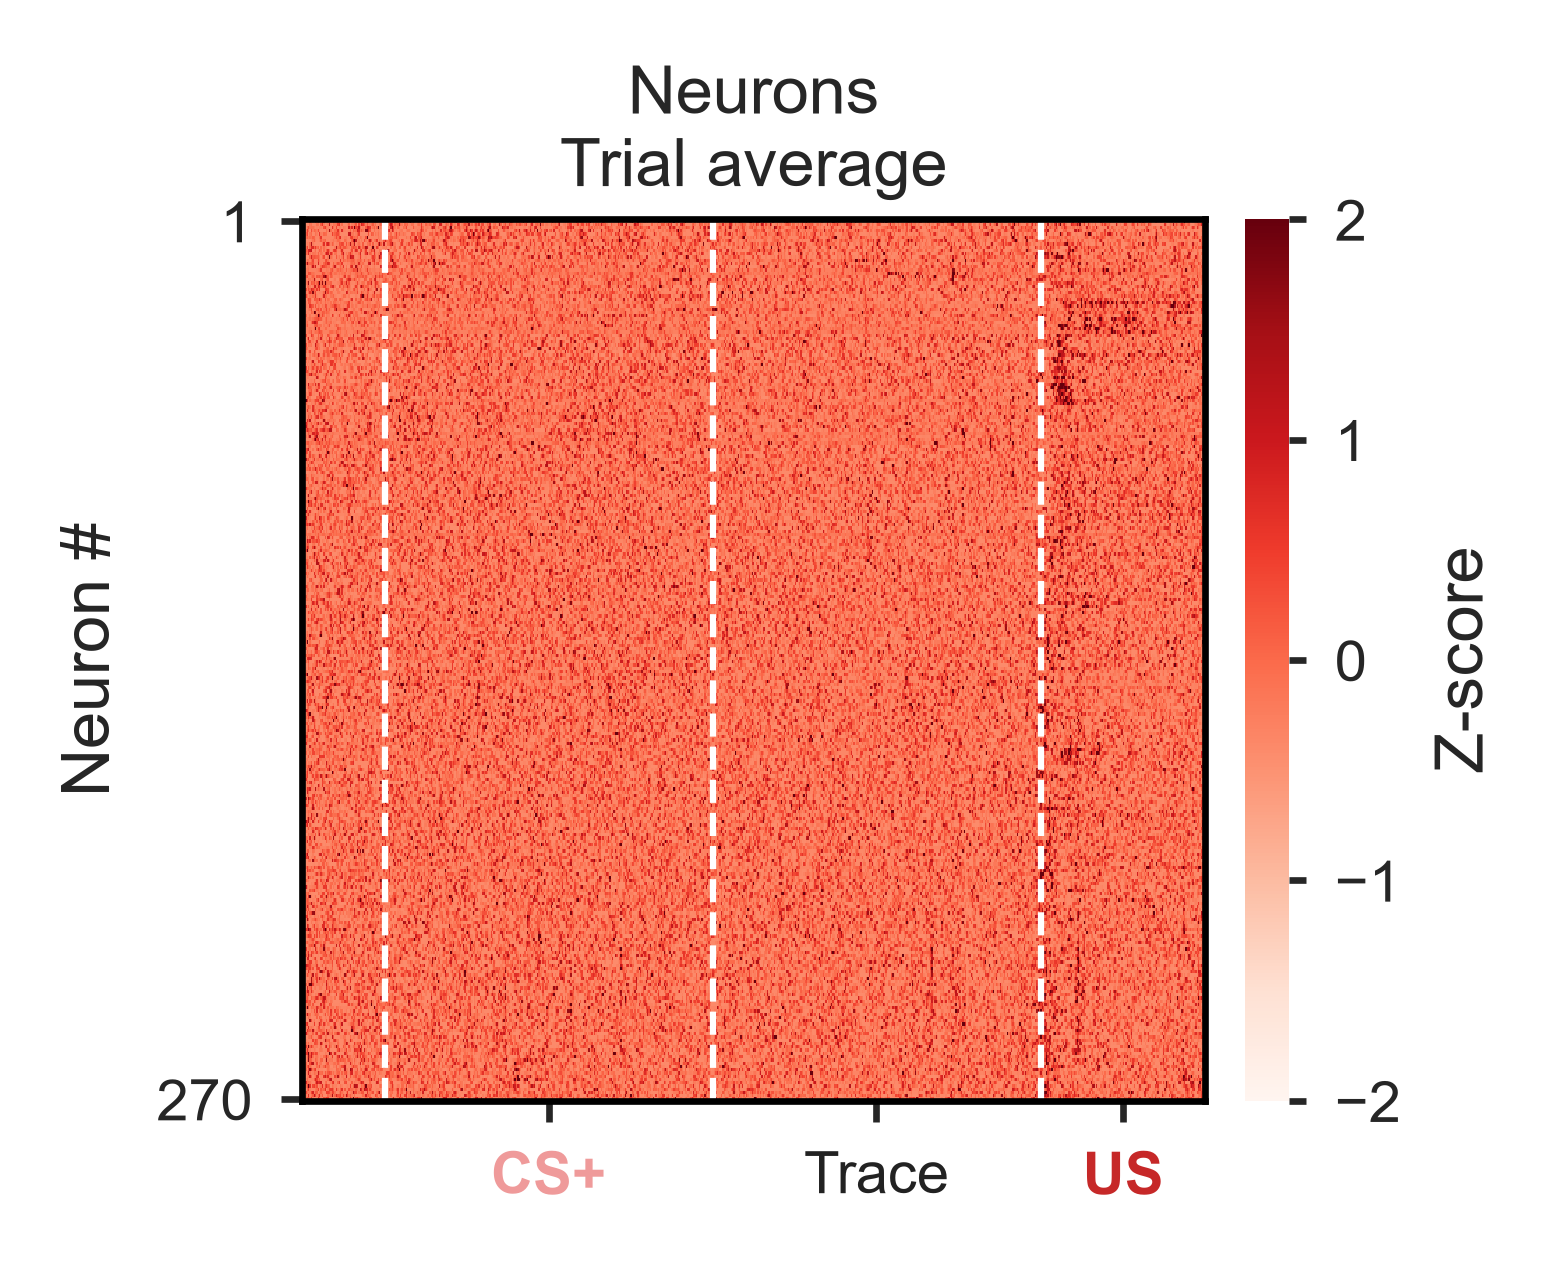

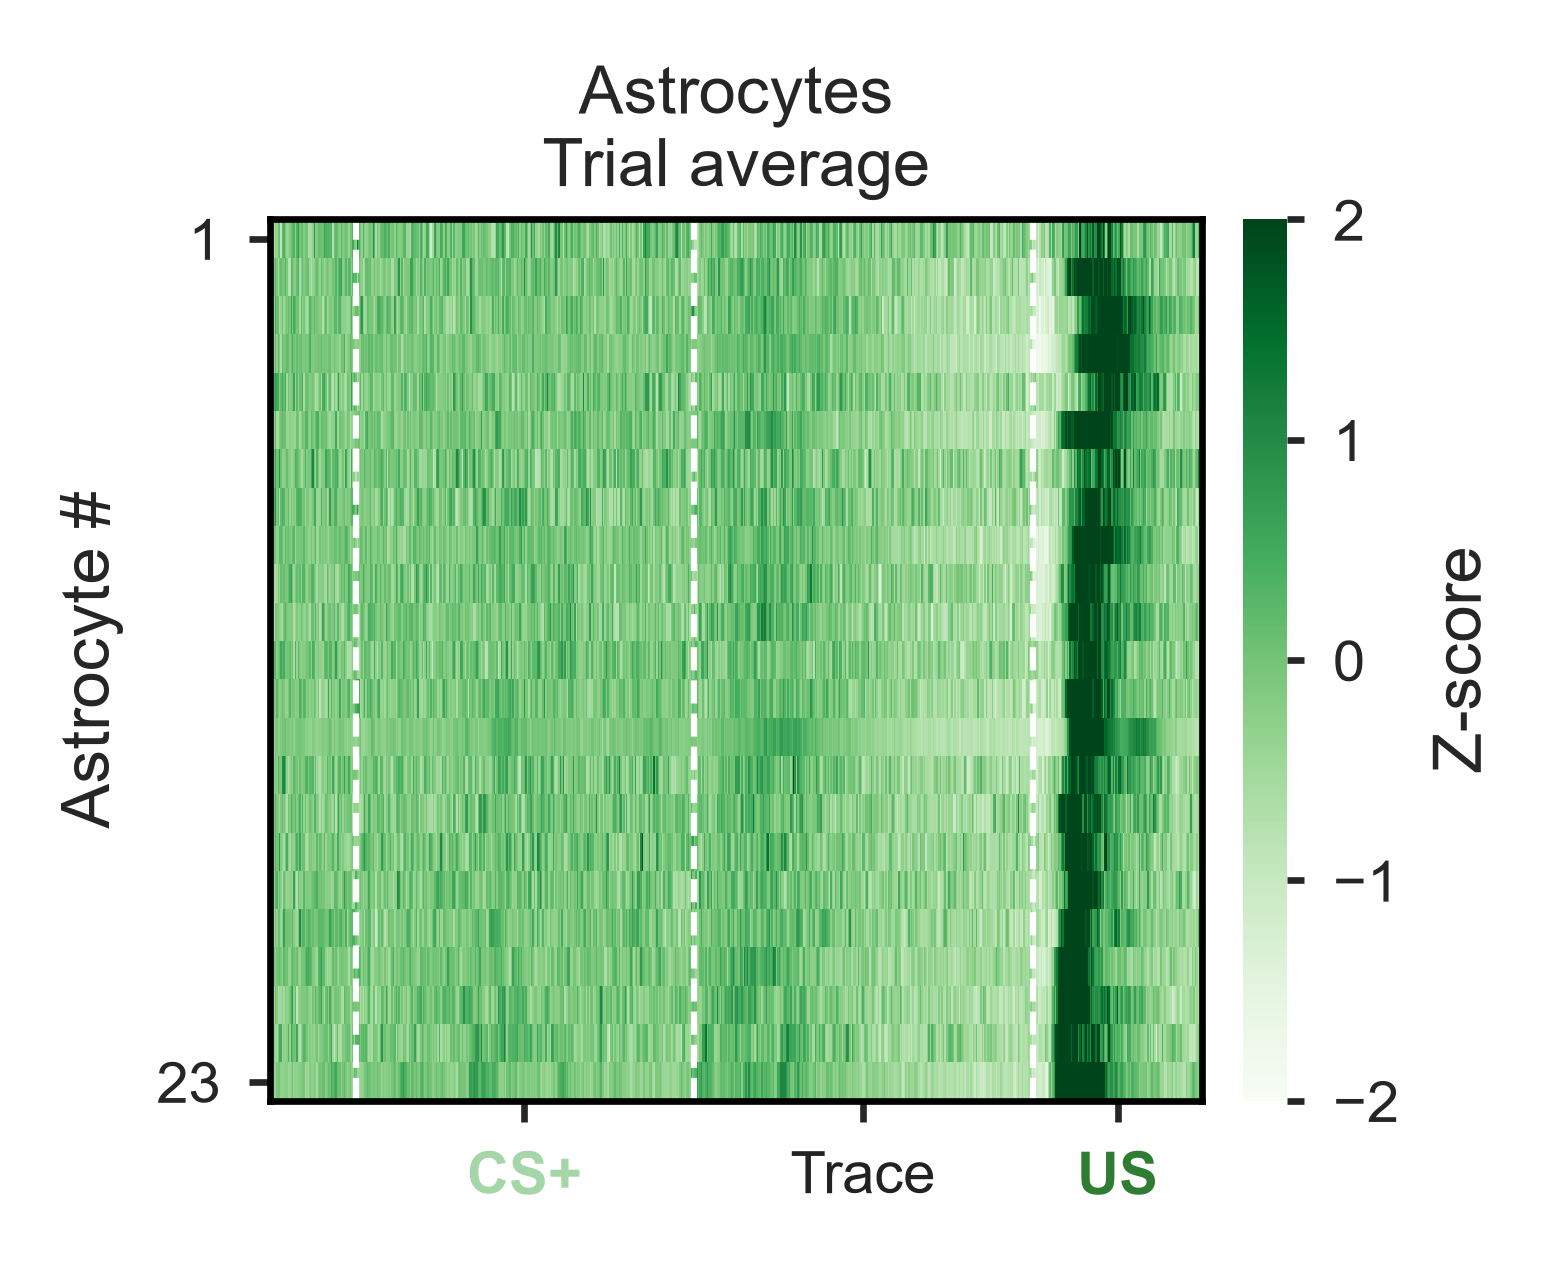

In [ ]:
#TRIAL-AVERAGE HEATMAPS

for dataset_name, cfg in DATASETS.items():
    plot_trial_average_heatmap(
        results[dataset_name],
        cfg,
        save_base=output_dirs["trial_average"] / f"{dataset_name}_trial_average_heatmap"
    )

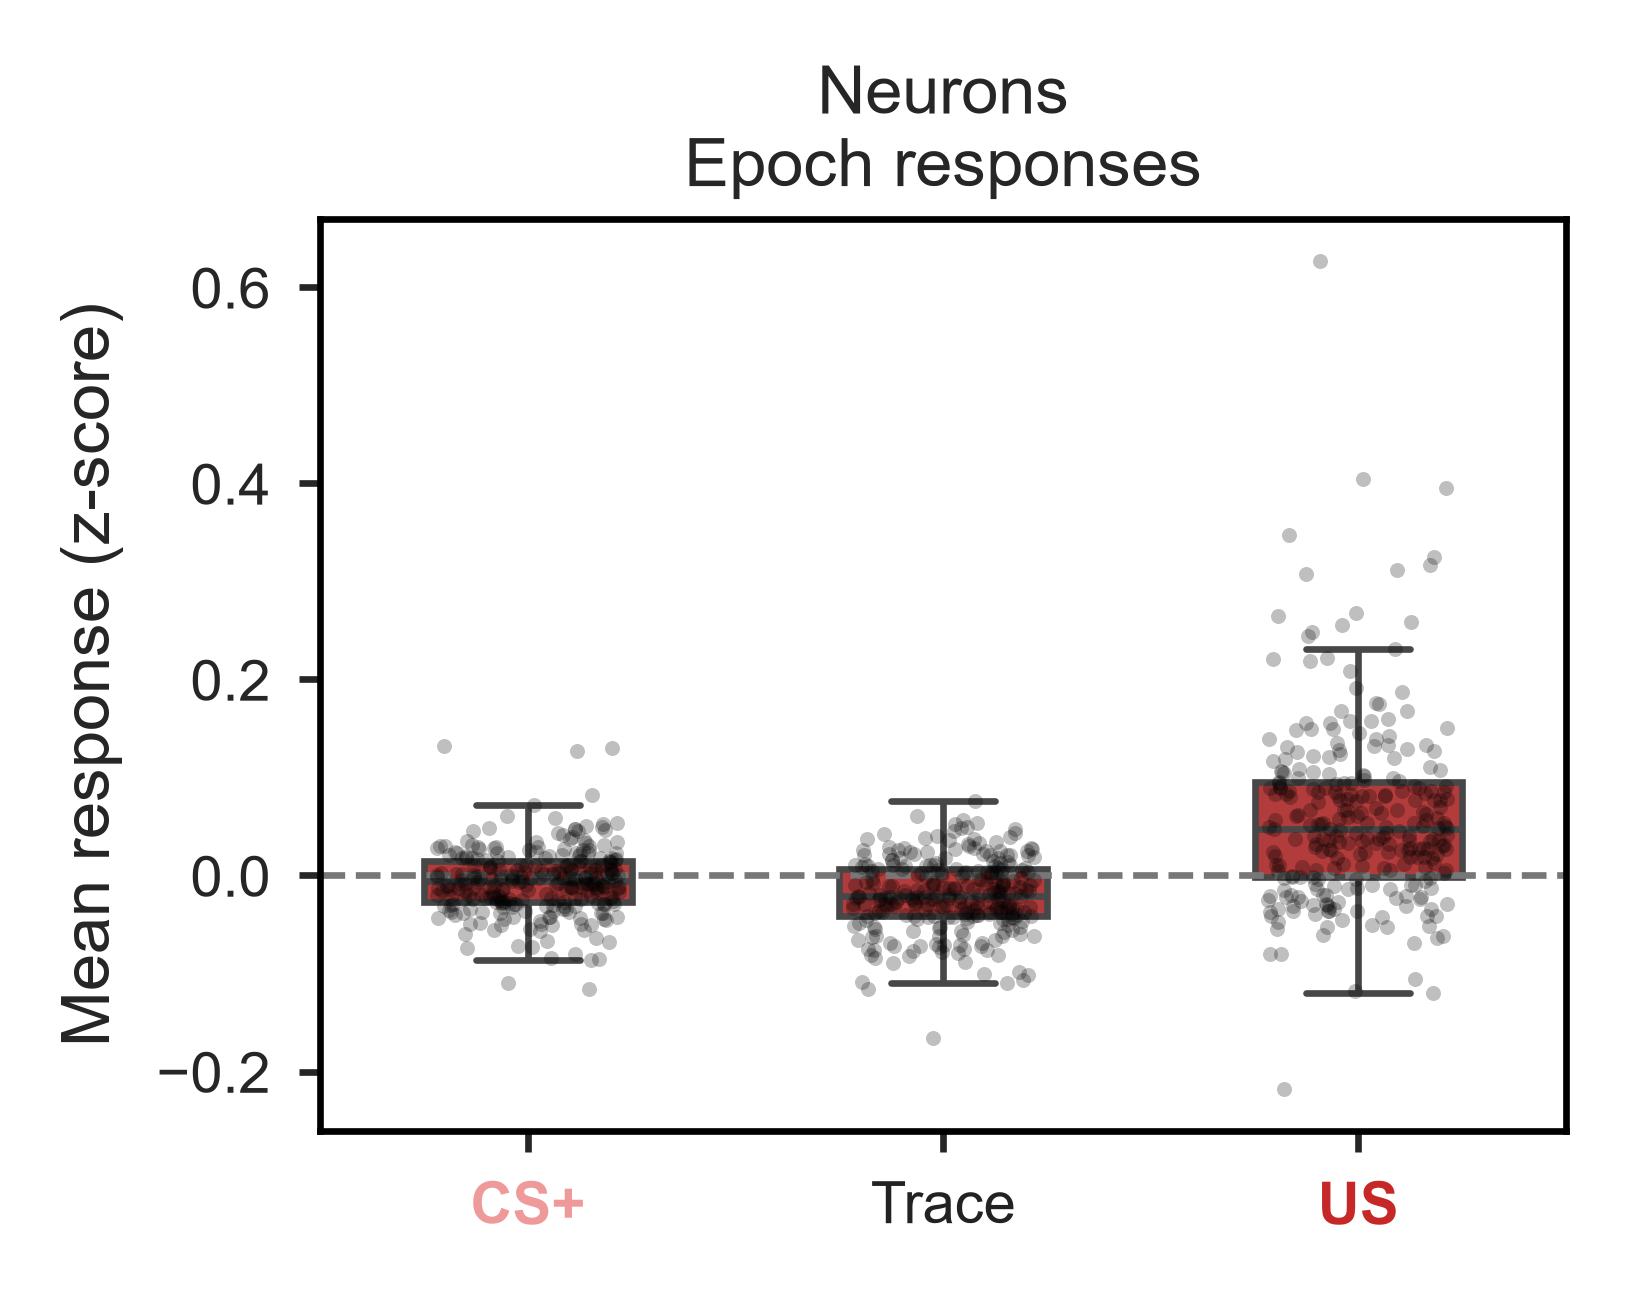

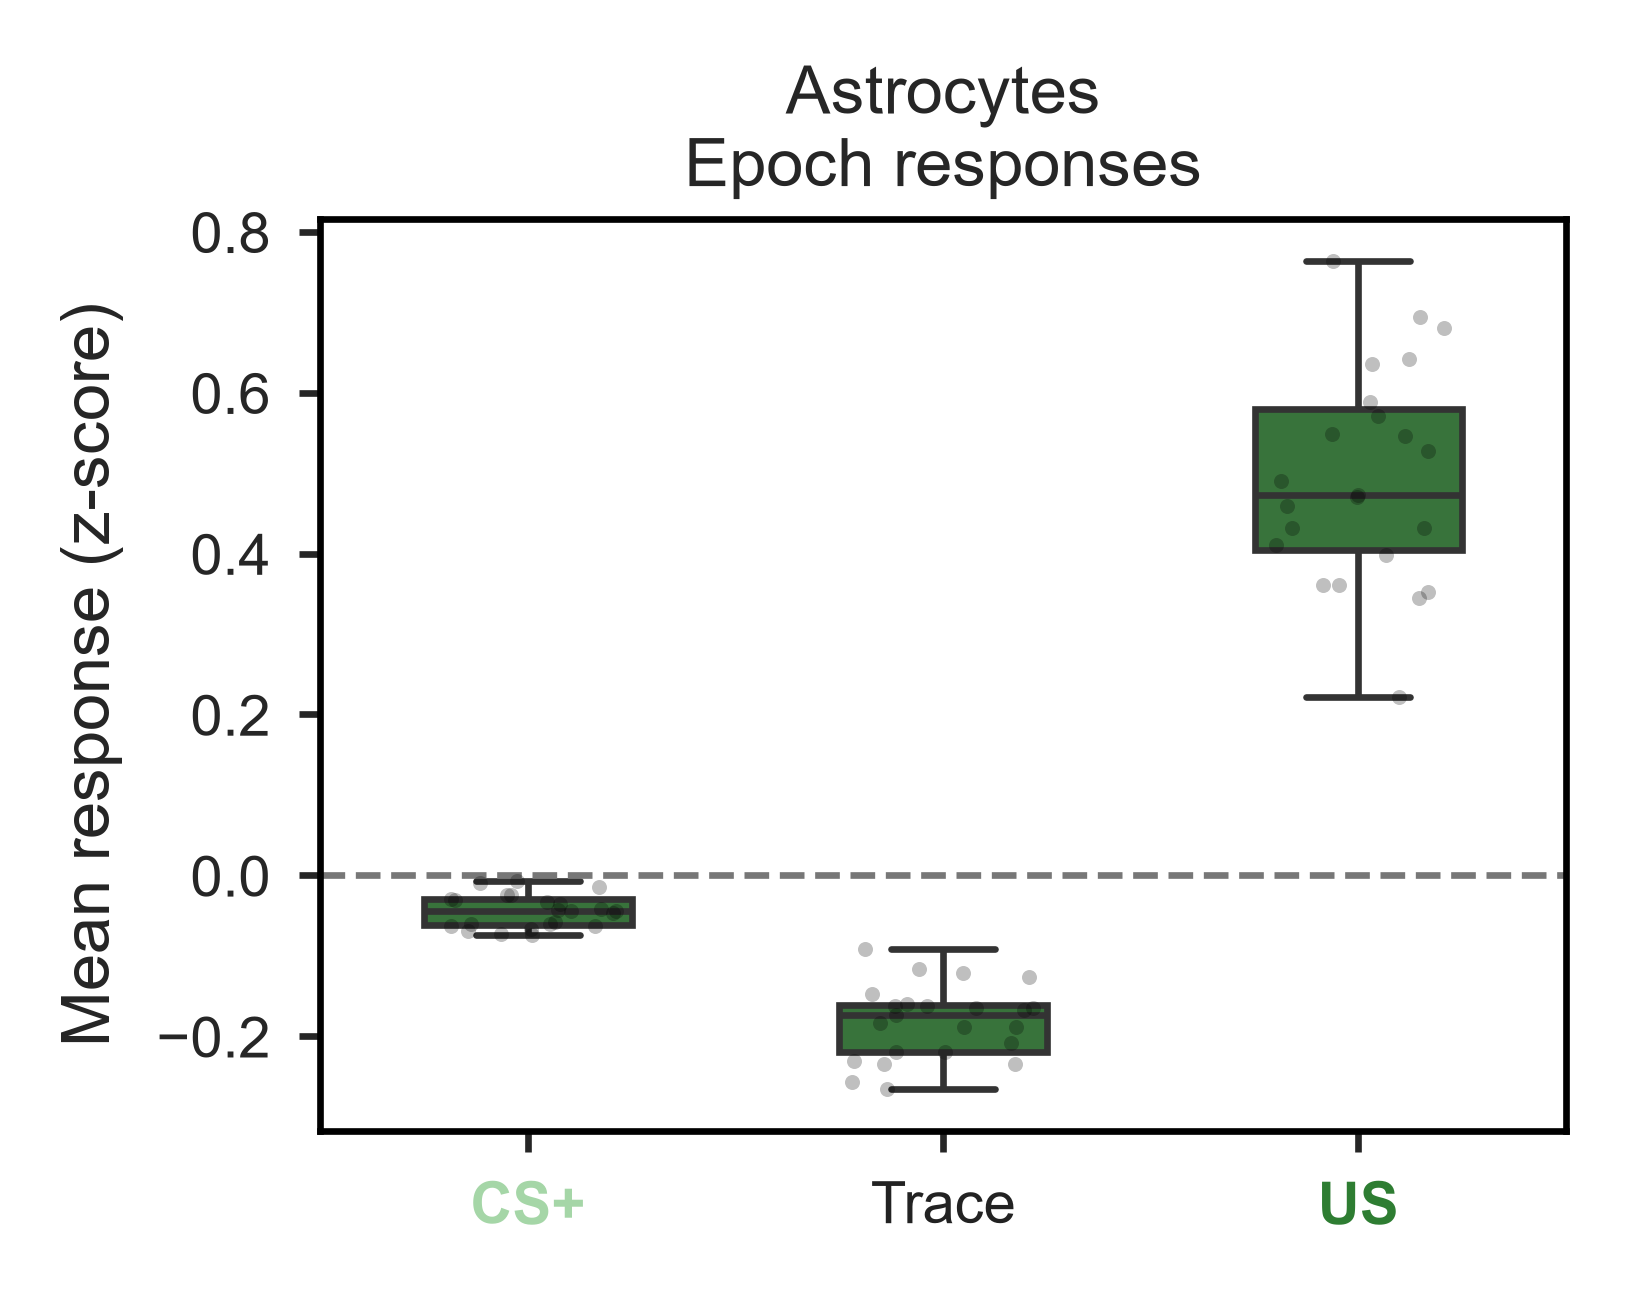

In [ ]:
#EPOCH QUANTIFICATION

for dataset_name, cfg in DATASETS.items():
    plot_epoch_quantification(
        results[dataset_name],
        cfg,
        save_base=output_dirs["epoch_quantification"] / f"{dataset_name}_epoch_quantification"
    )

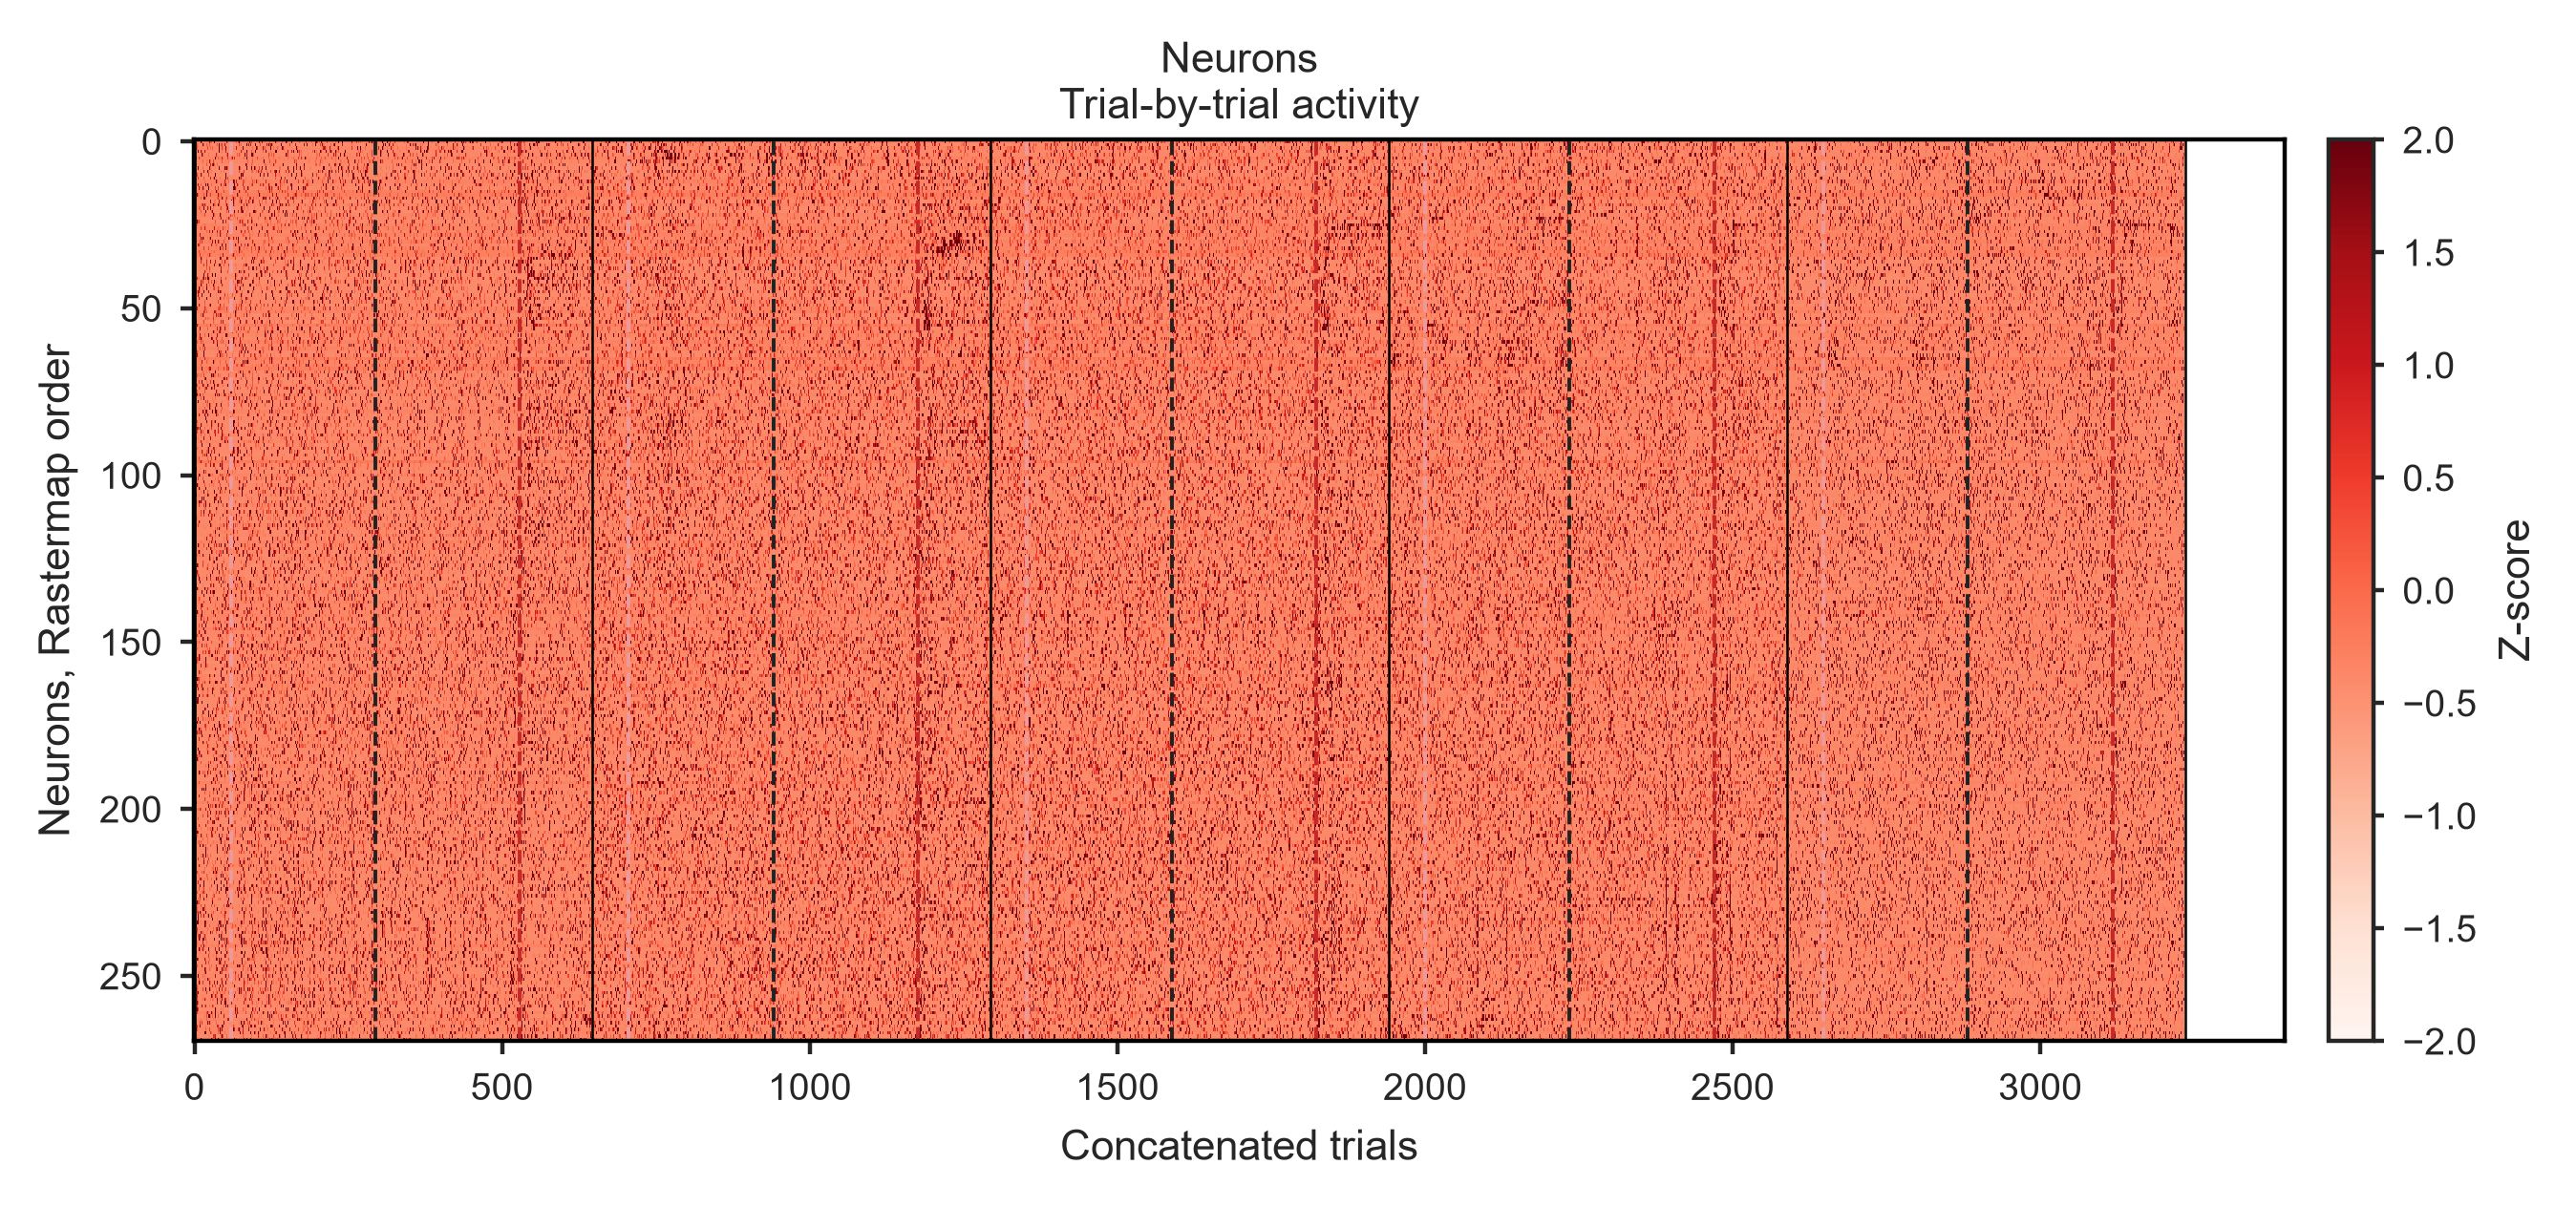

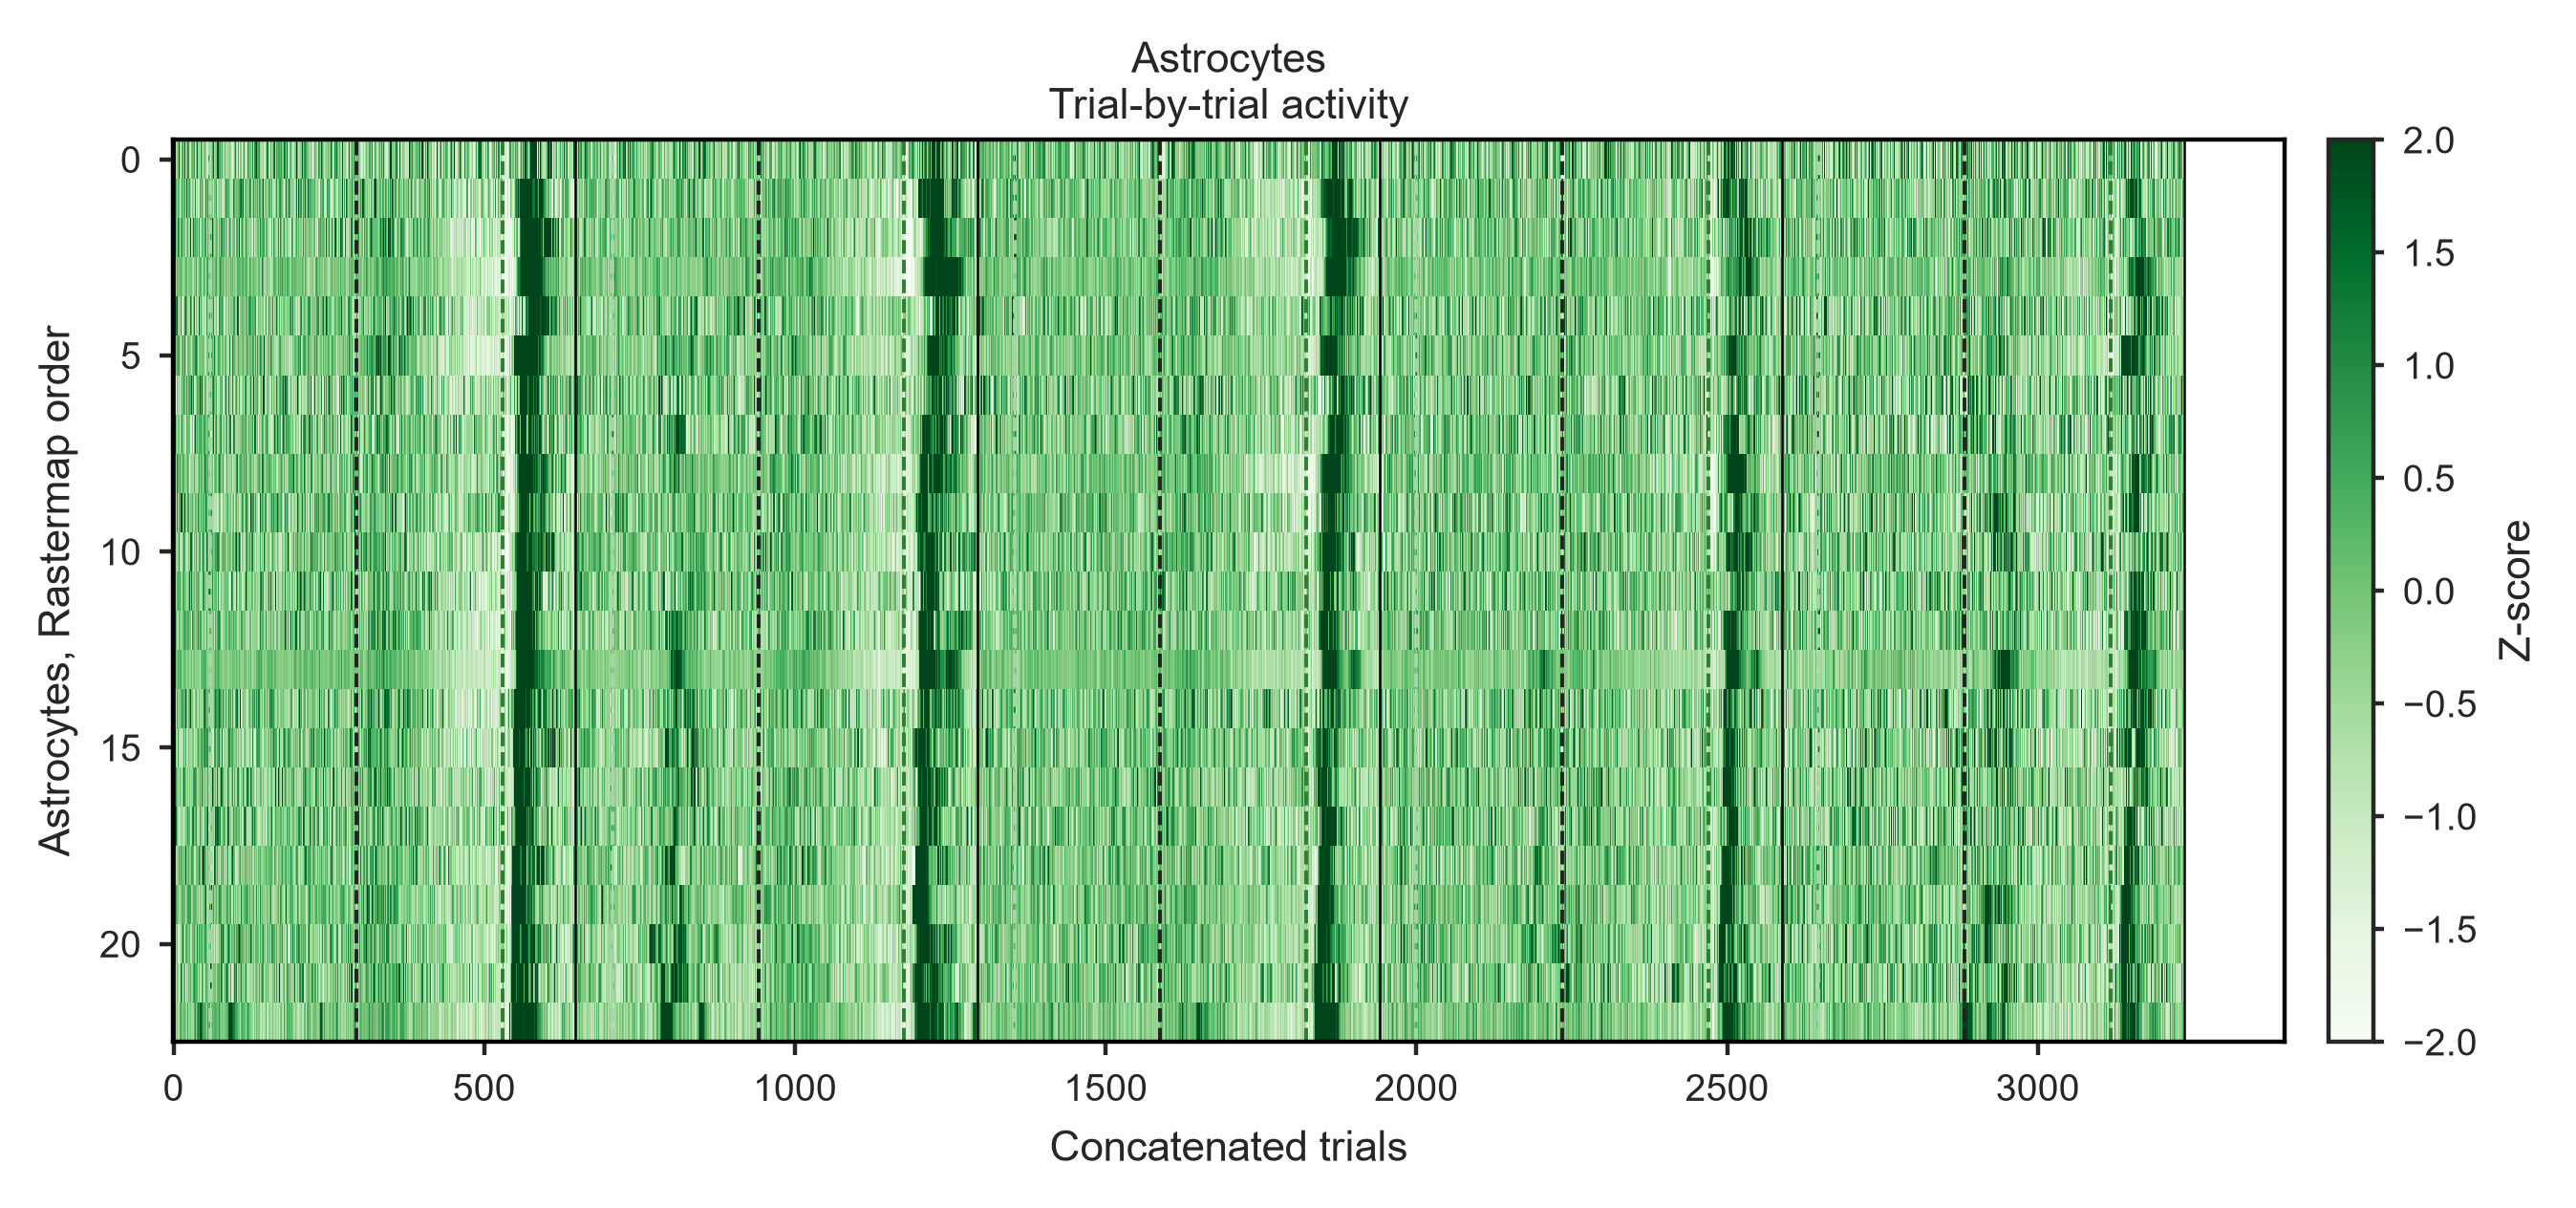

In [ ]:
#TRIAL-BY-TRIAL RASTERMAP


for dataset_name, cfg in DATASETS.items():
    plot_trial_by_trial_rastermap(
        results[dataset_name],
        cfg,
        save_base=output_dirs["trial_by_trial"] / f"{dataset_name}_trial_by_trial_rastermap"
    )

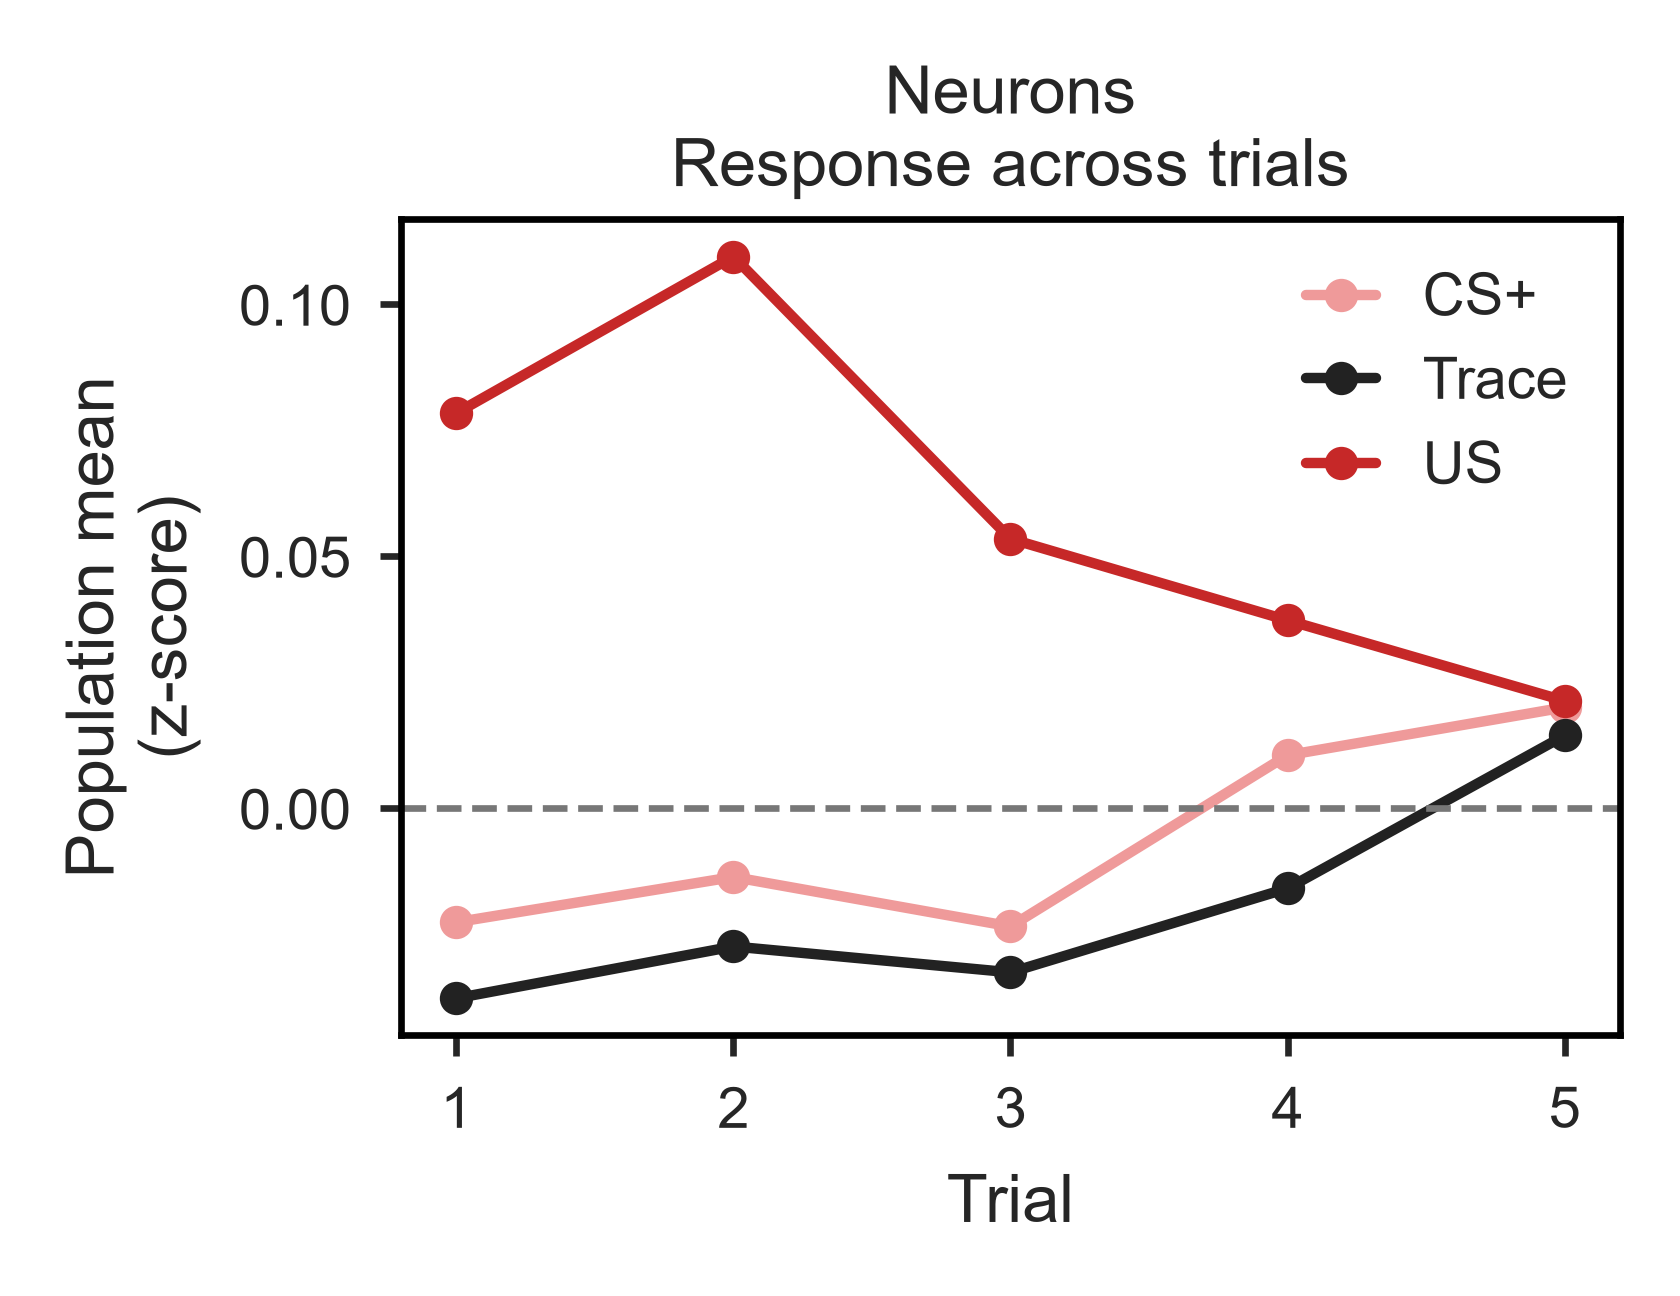

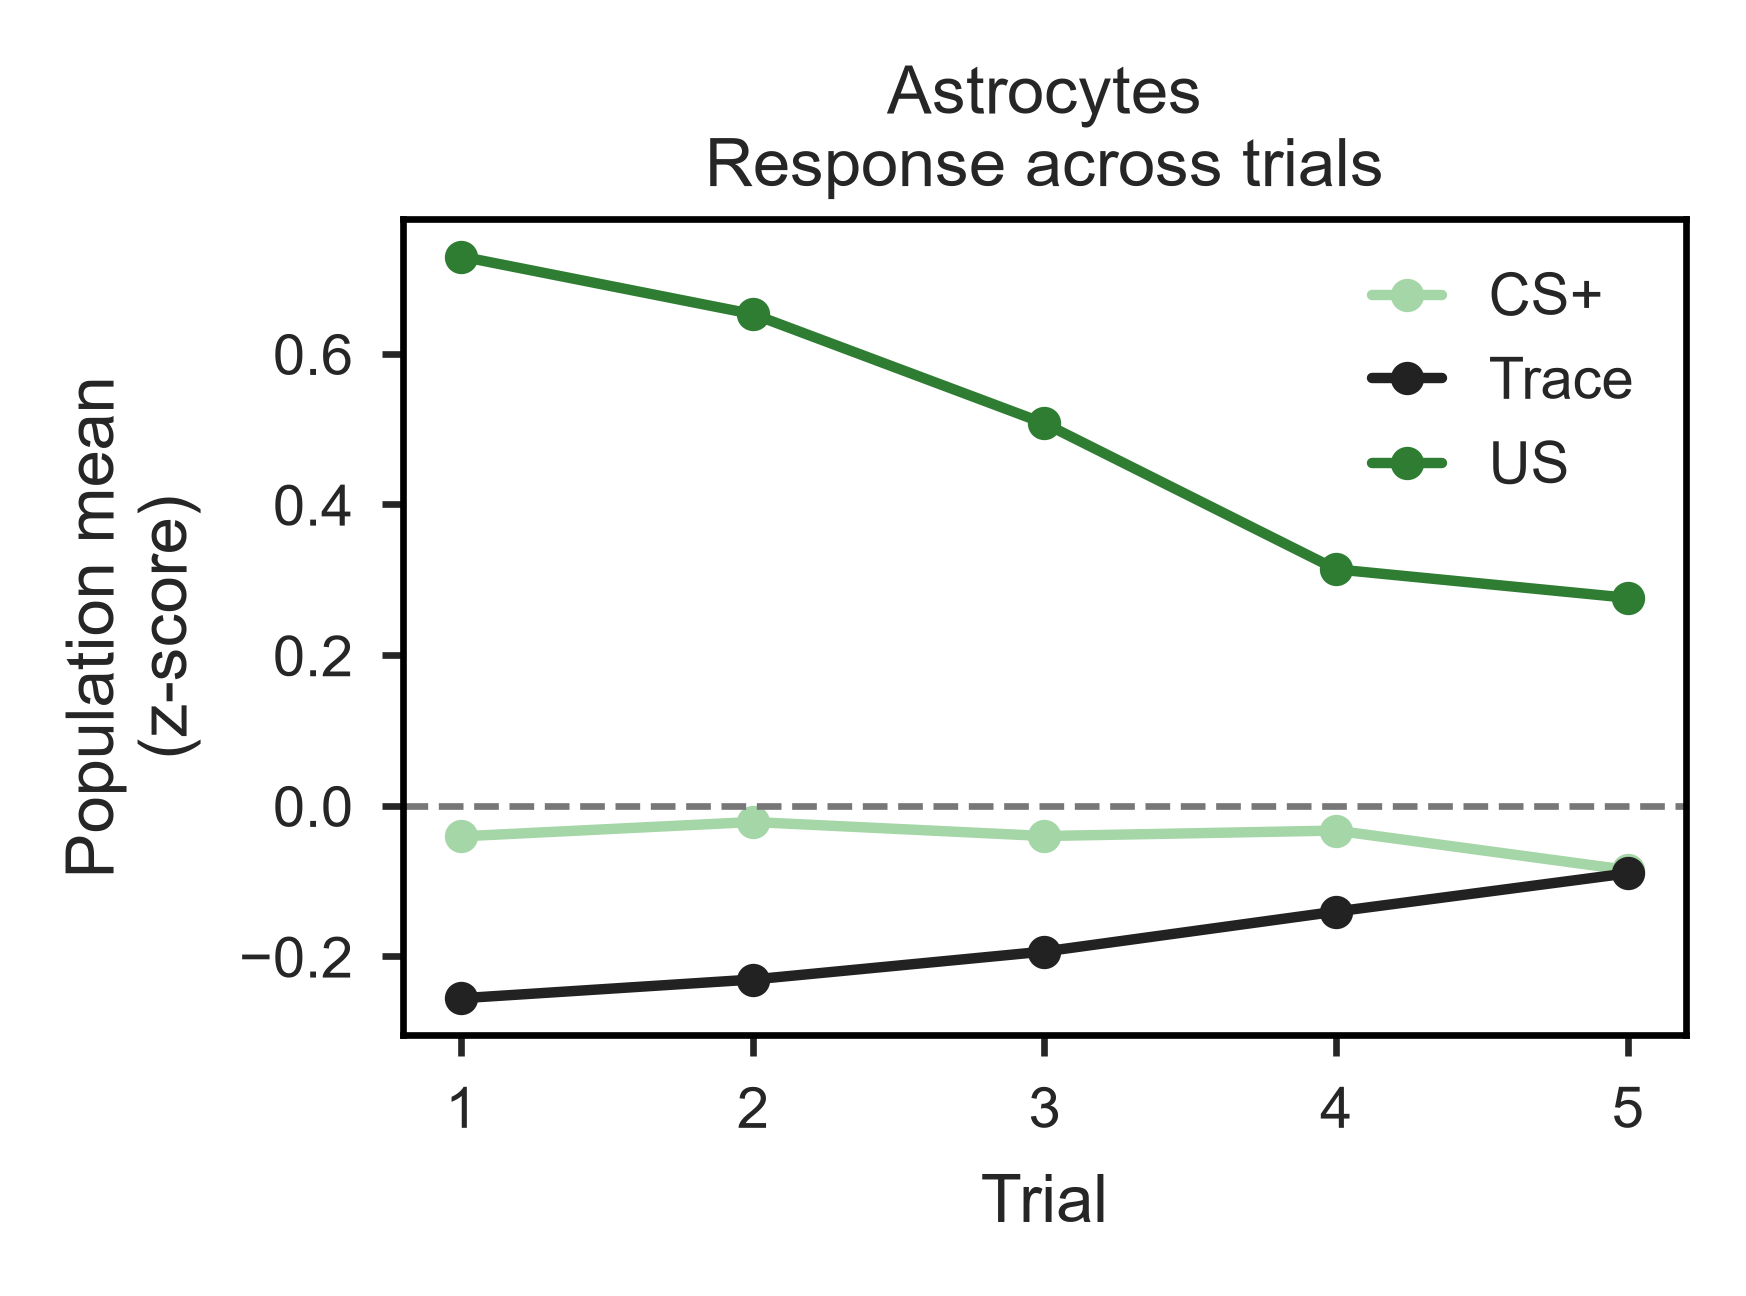

In [ ]:
# POPULATION RESPONSE ACROSS TRIALS
for dataset_name, cfg in DATASETS.items():
    plot_response_across_trials(
        results[dataset_name],
        cfg,
        save_base=output_dirs["trial_by_trial"] / f"{dataset_name}_response_across_trials"
    )

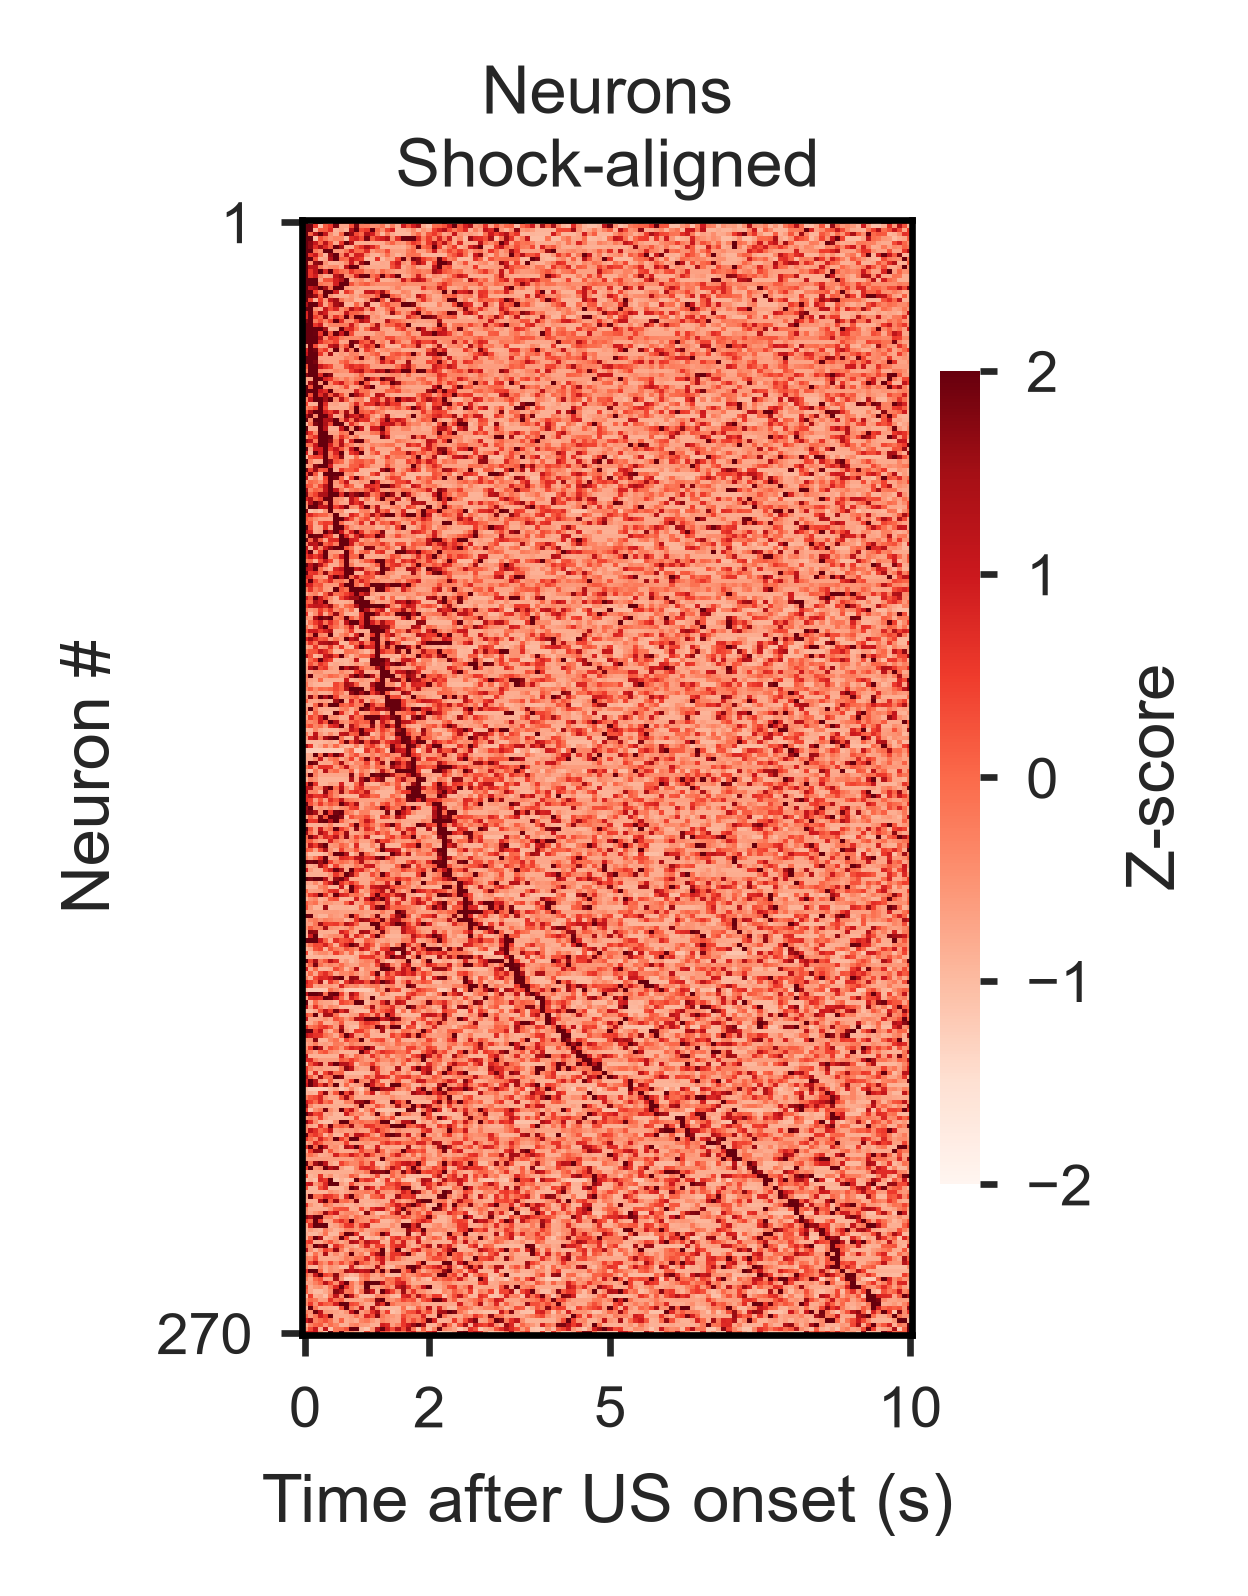

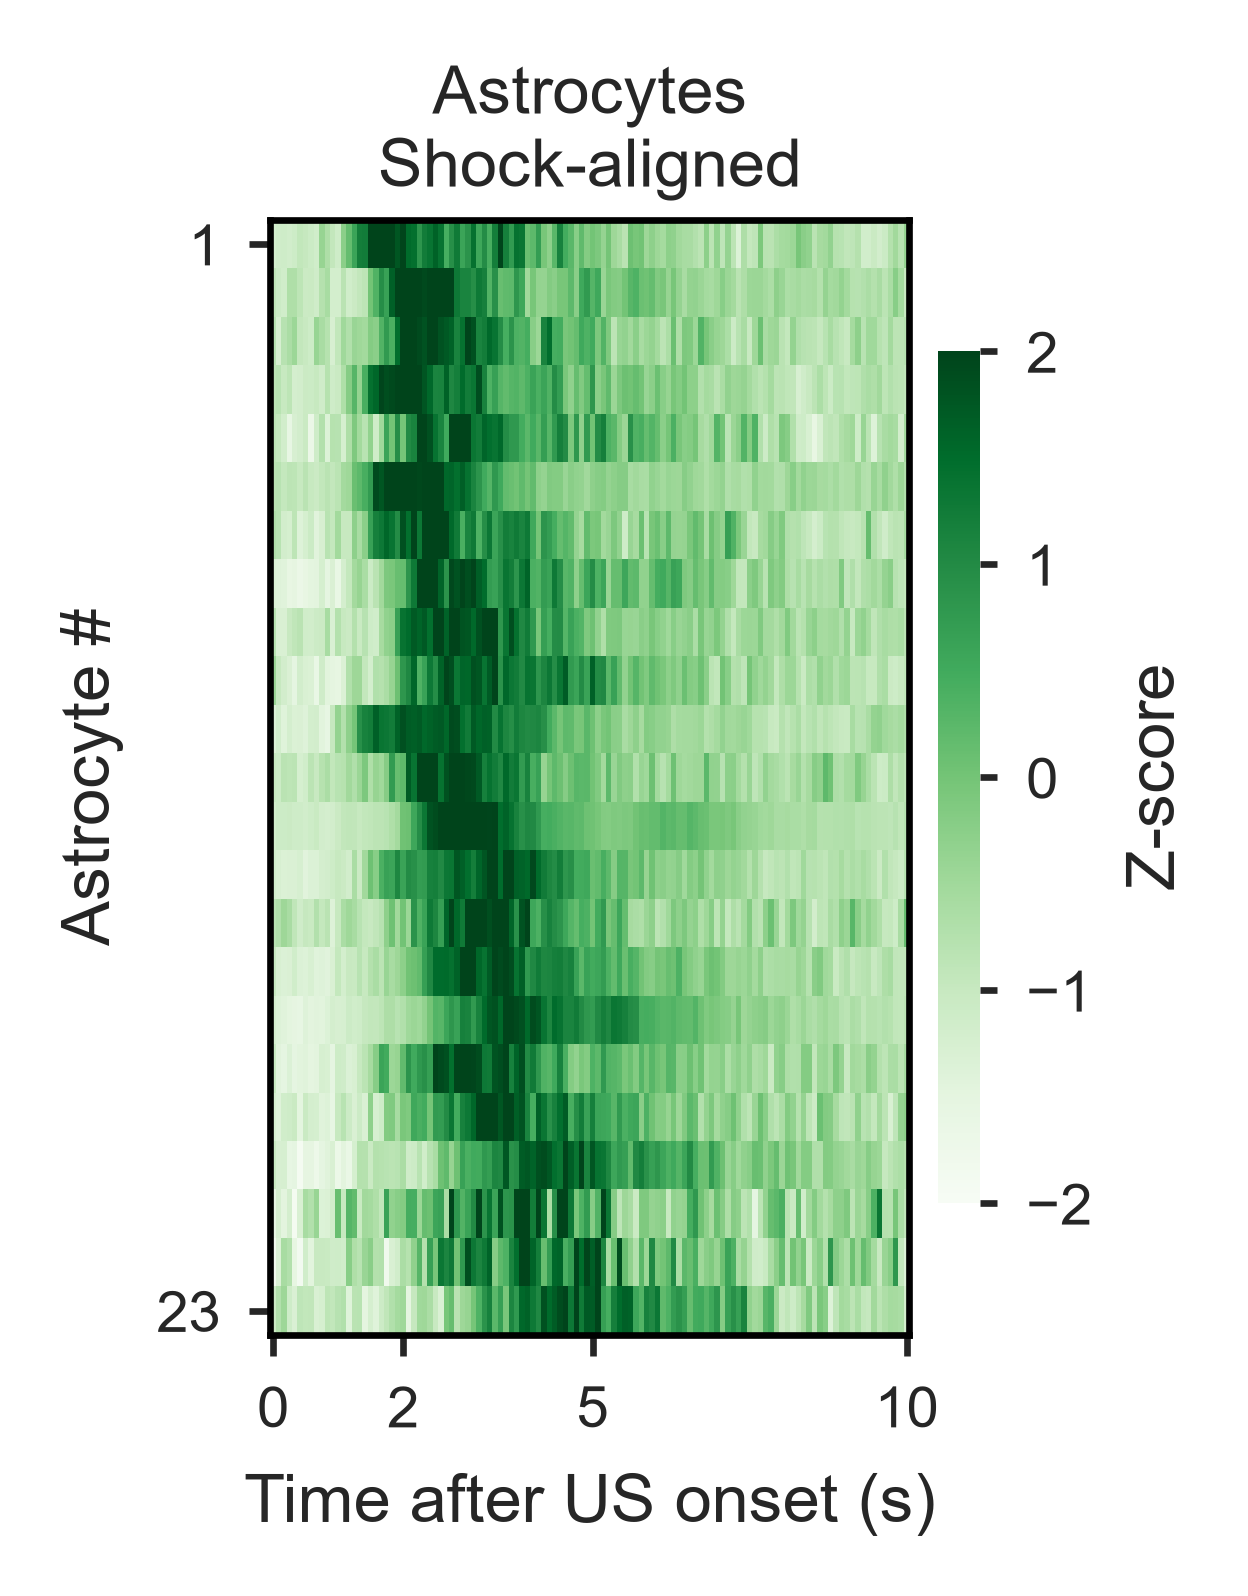

In [ ]:
#SHOCK-ALIGNED HEATMAP

for dataset_name, cfg in DATASETS.items():
    plot_shock_aligned_heatmap(
        results[dataset_name],
        cfg,
        save_base=output_dirs["shock_aligned"] / f"{dataset_name}_shock_aligned_heatmap"
    )

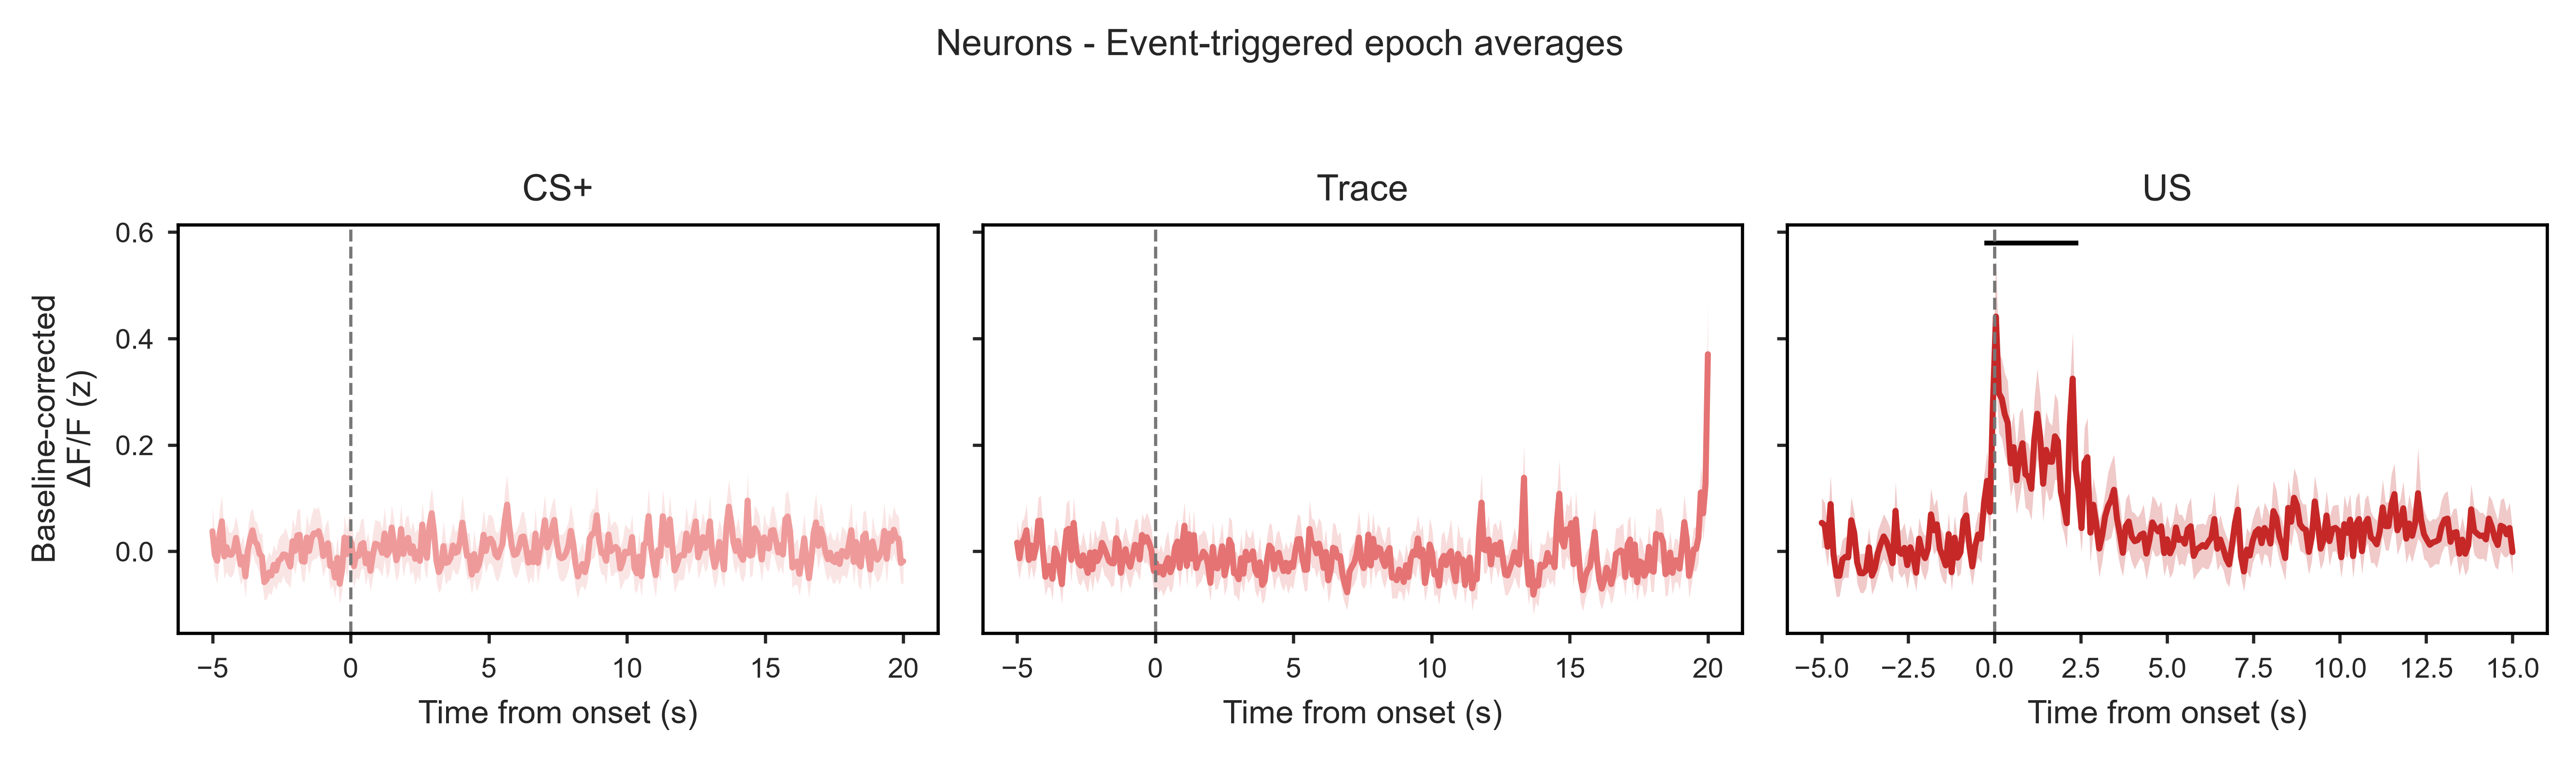

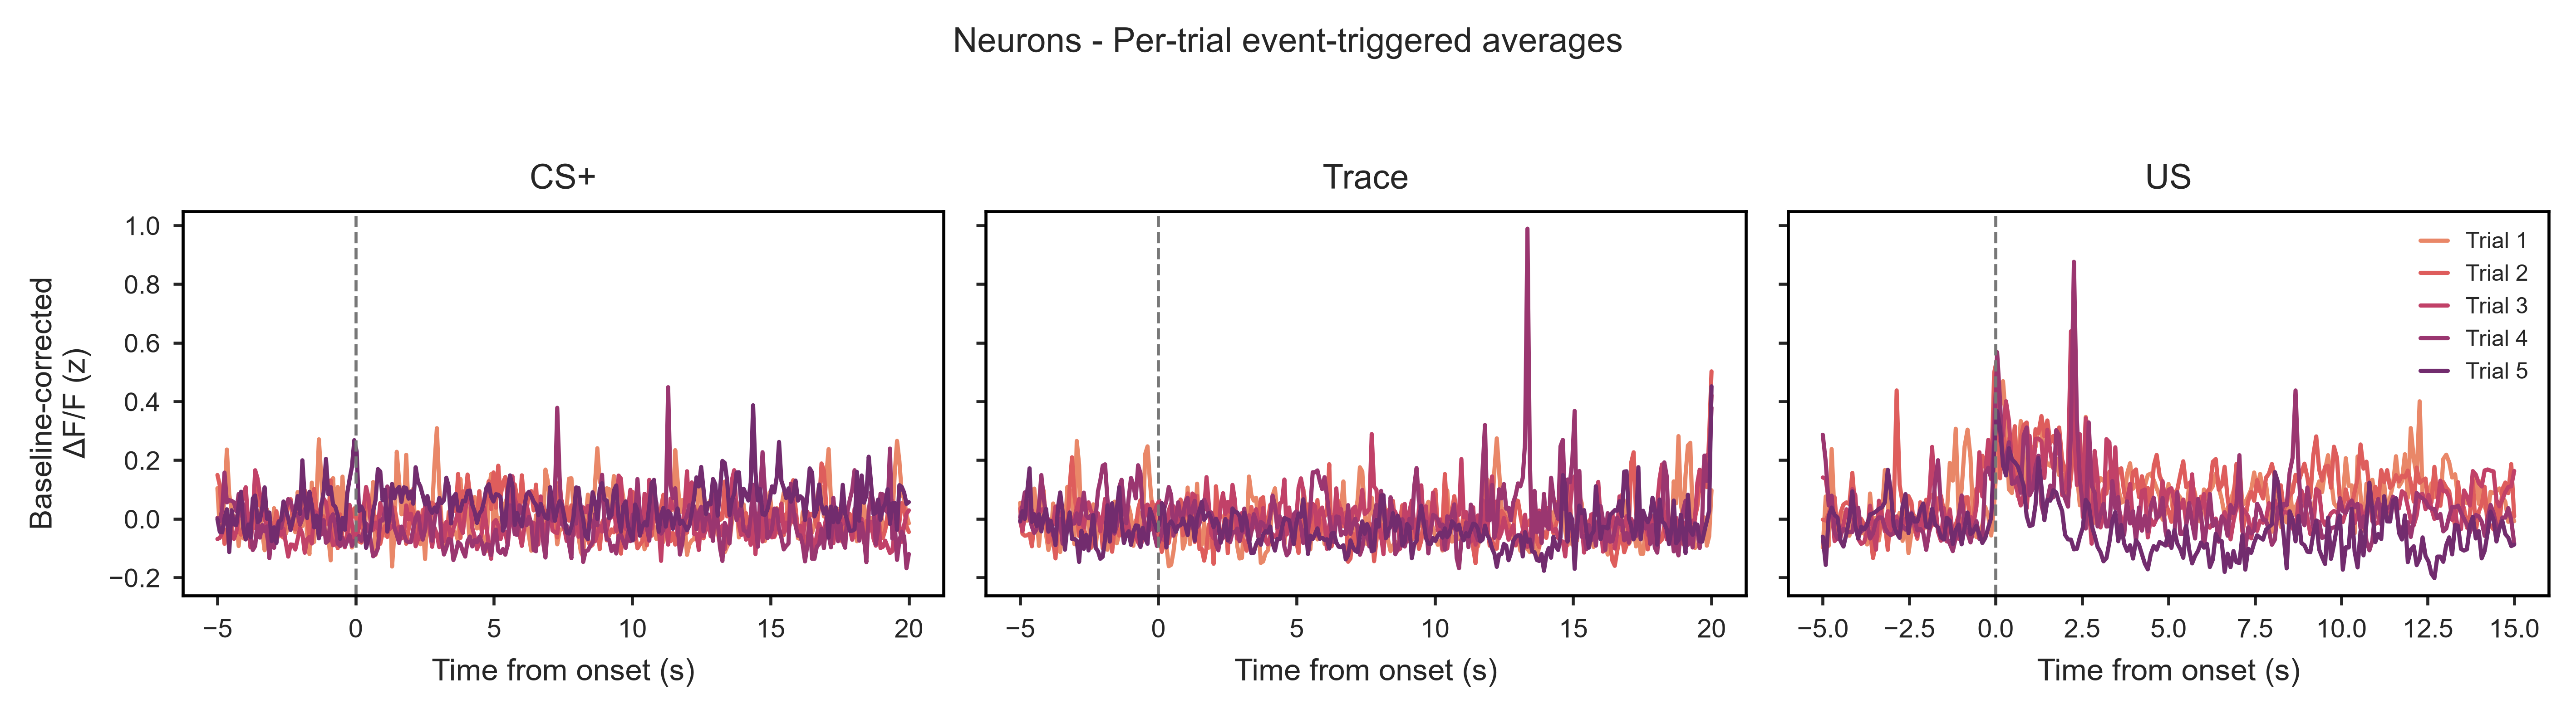

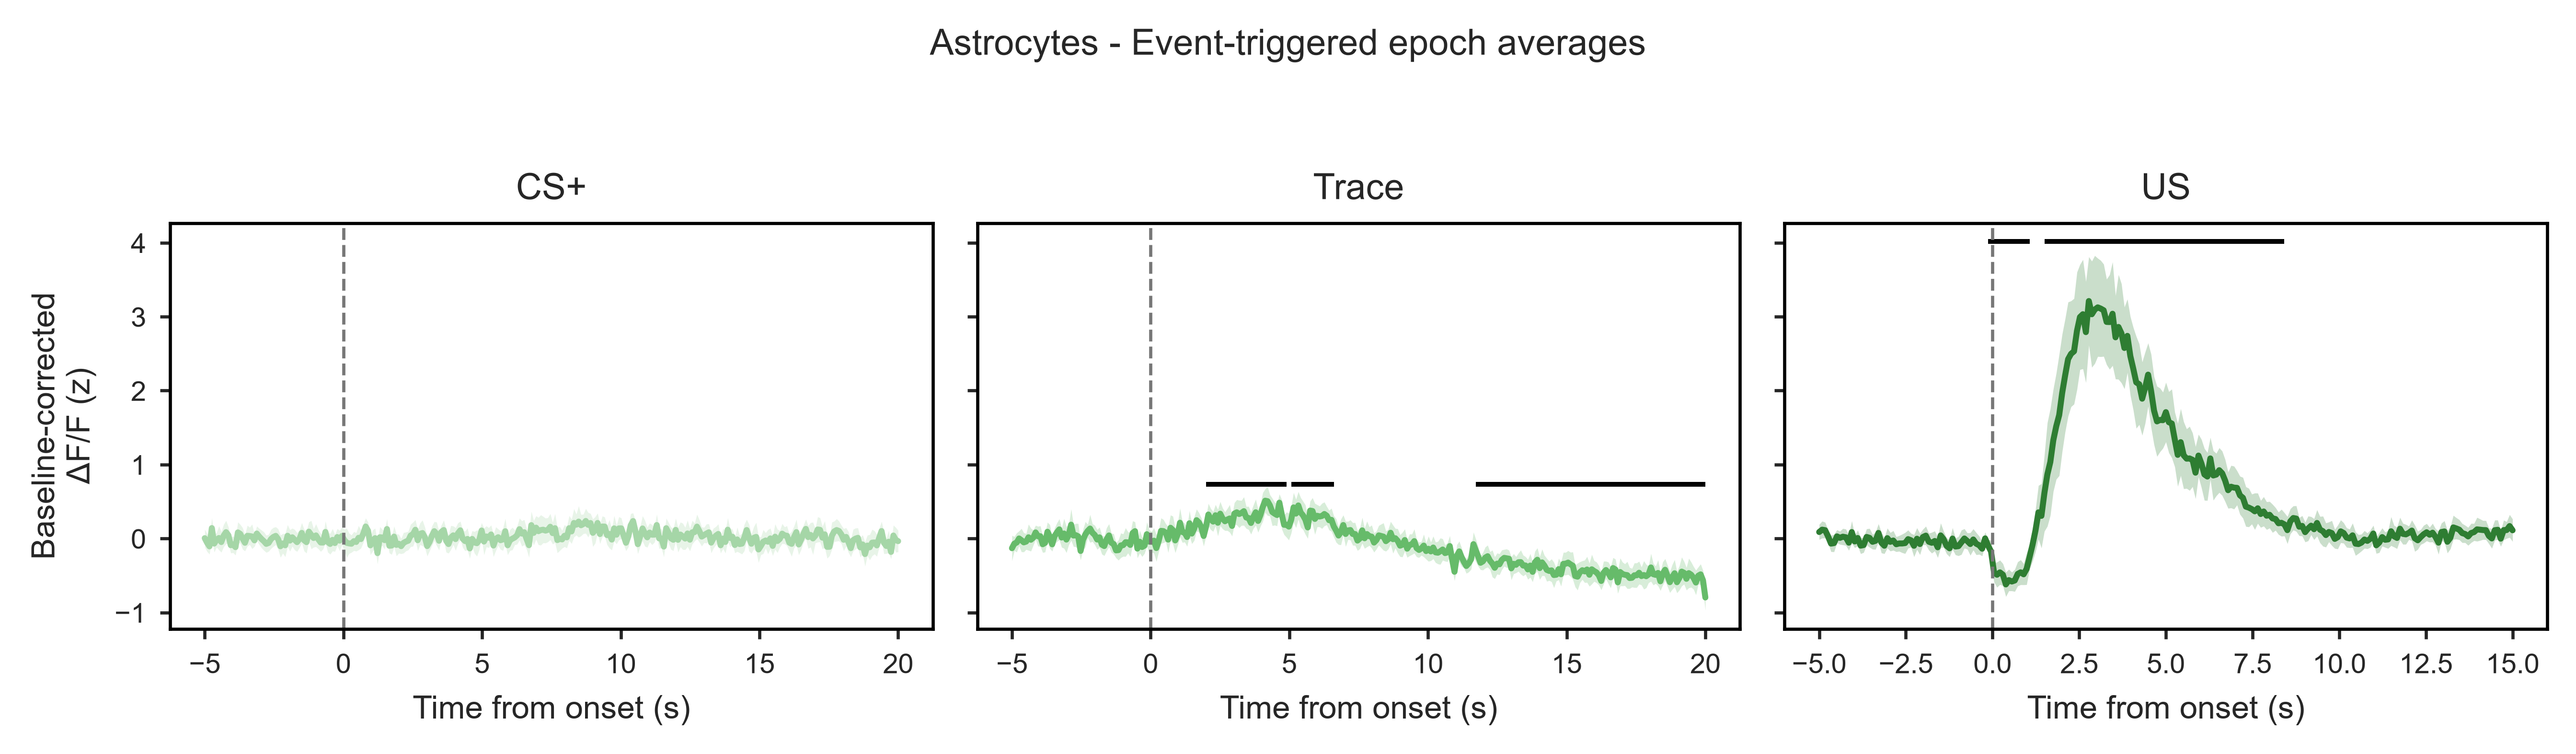

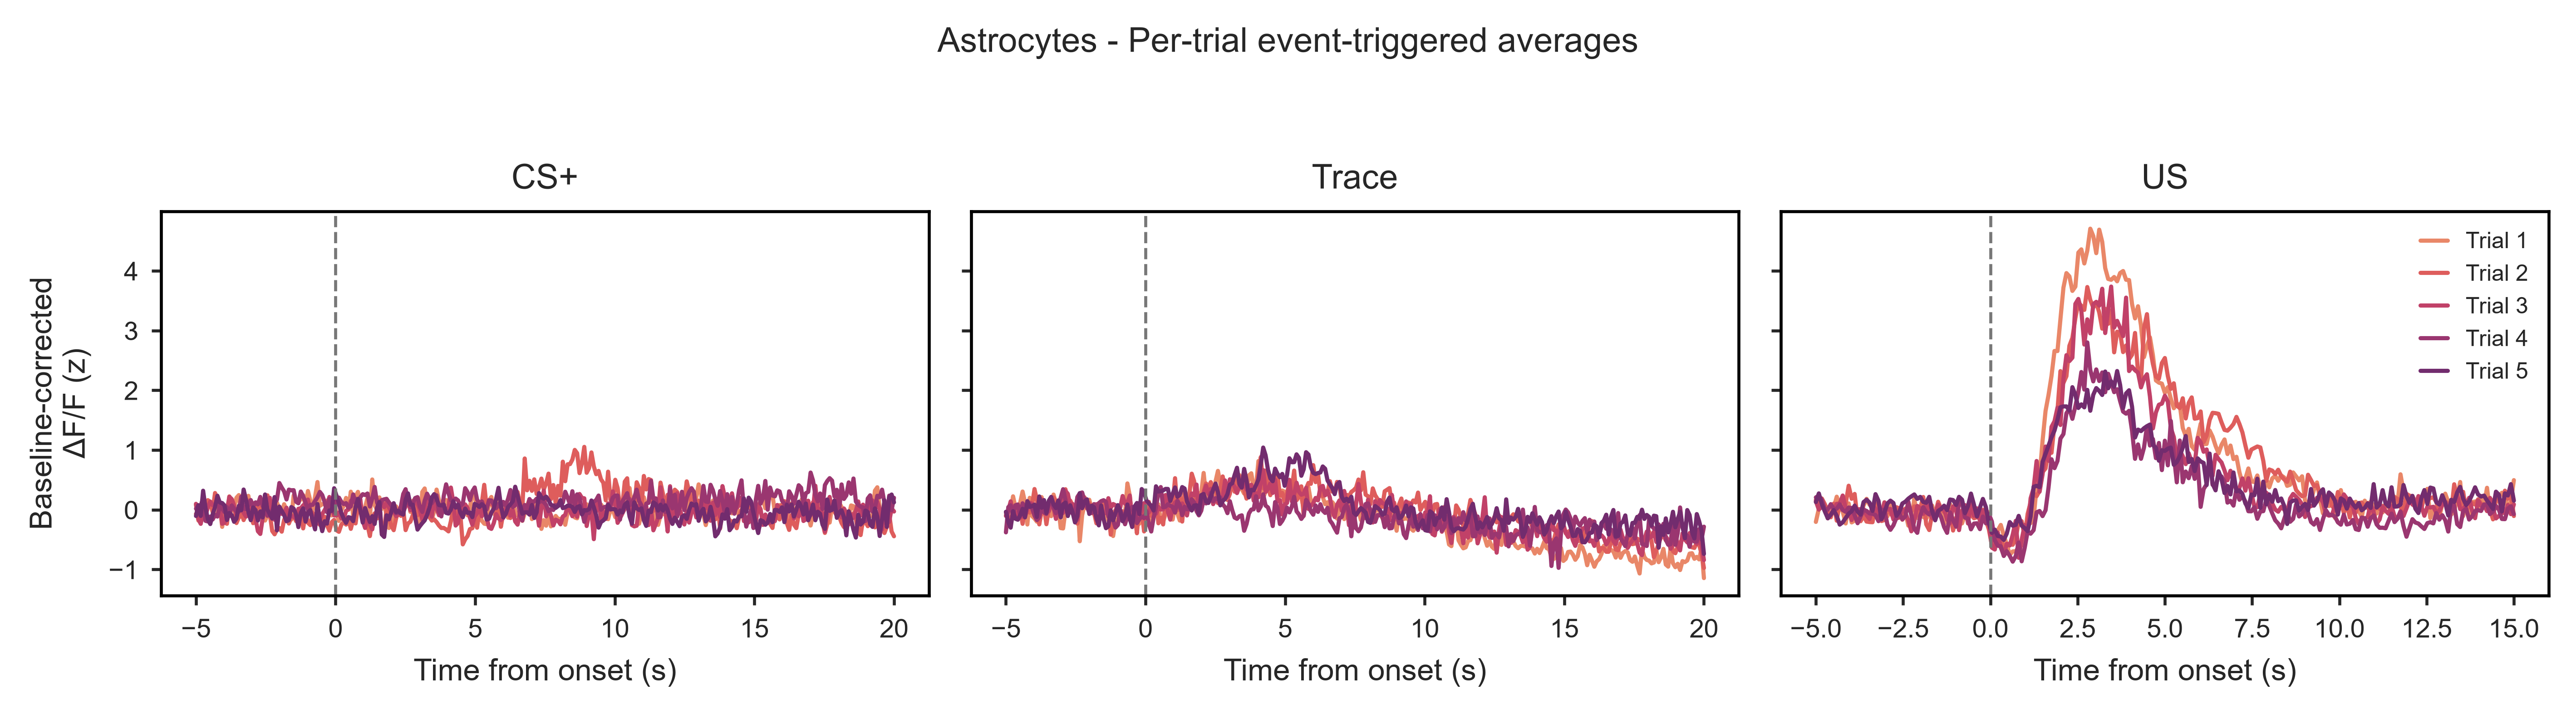

In [ ]:
#EVENT-TRIGGERED EPOCH AVERAGES (CS+ / TRACE / US)
for dataset_name, cfg in DATASETS.items():
    plot_epoch_eta_grid(
        results[dataset_name],
        cfg,
        save_base=output_dirs["epoch_traces"] / f"{dataset_name}_epoch_eta_grid"
    )
